<h1>Closed - Set ResNet50 + BioClinicalBERT (cross attention)</h1>


DATASET COMPARISON TABLE


,Dataset,Total samples,Available images,Total classes,Known classes,Unknown / target-only classes,Metadata availability,Imaging type
0,PAD-UFES-20,2298,2298,6,"AK, BCC, MEL, NEV, SCC, SK",None,Rich,Clinical smartphone
1,ISIC 2019,33569,33569,9,"AK, BCC, MEL, NEV, SCC, SK","ANG, DF, UNK",Limited / moderate,Dermoscopic
2,MCR-SL,235,230,9,"AK, BCC, MEL, NEV, SCC, SK","ANG, ATY, DF",Sparse / heterogeneous,Clinical / heterogeneous


Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\dataset_comparison_table.csv

LABEL OVERLAP TABLE


,Label,PAD-UFES-20,ISIC 2019,MCR-SL,Known / Unknown
0,AK,Yes,Yes,Yes,Known
1,ANG,No,Yes,Yes,Unknown / target-only
2,ATY,No,No,Yes,Unknown / target-only
3,BCC,Yes,Yes,Yes,Known
4,DF,No,Yes,Yes,Unknown / target-only
5,MEL,Yes,Yes,Yes,Known
6,NEV,Yes,Yes,Yes,Known
7,SCC,Yes,Yes,Yes,Known
8,SK,Yes,Yes,Yes,Known
9,UNK,No,Yes,No,Unknown / target-only


Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\label_overlap_table.csv
Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\class_distribution_counts.csv


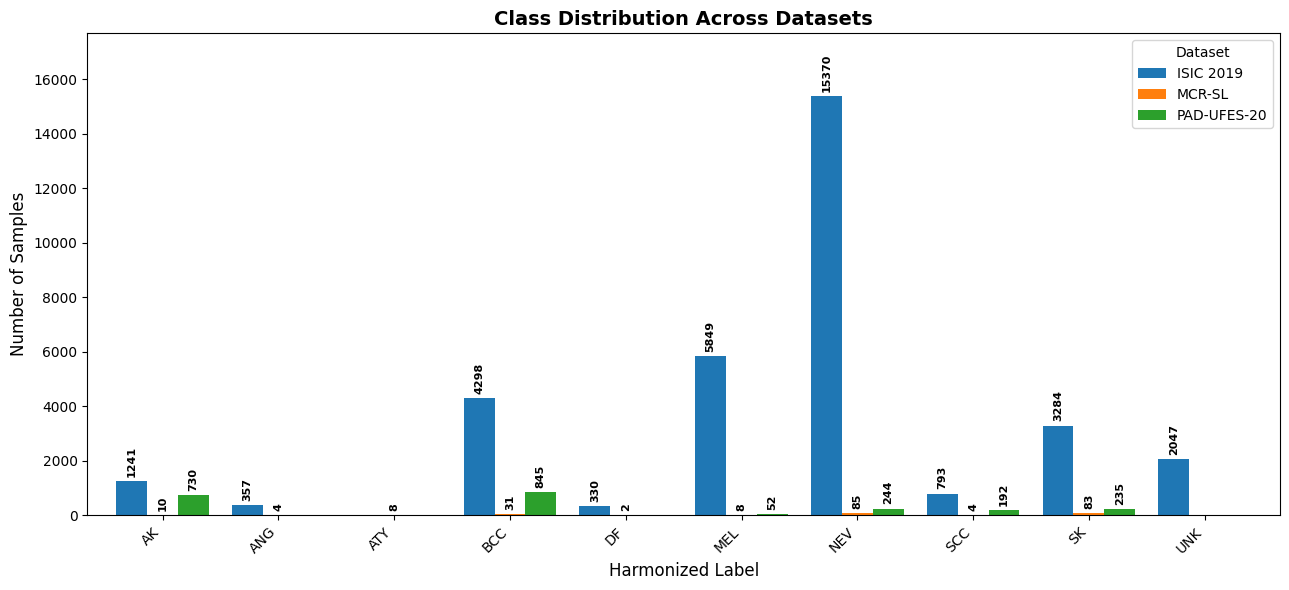

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\class_distribution_across_datasets_labeled.png


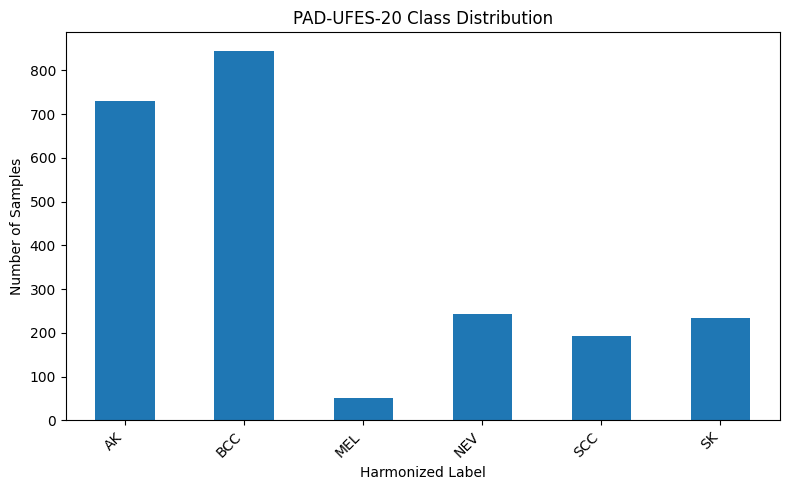

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\PAD_UFES_20_class_distribution.png


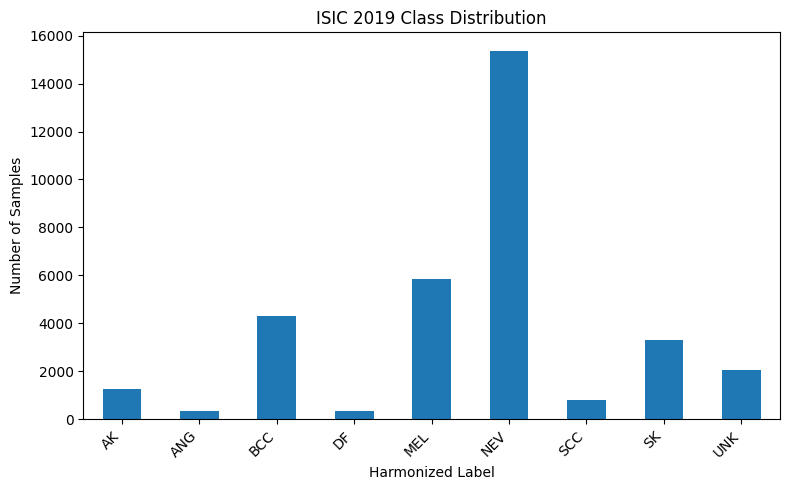

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\ISIC_2019_class_distribution.png


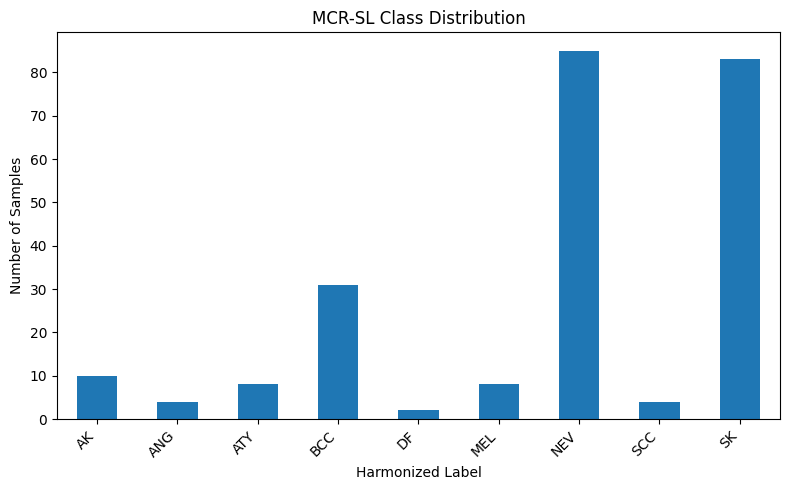

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\MCR_SL_class_distribution.png

METADATA AVAILABILITY TABLE


,Feature,PAD-UFES-20,ISIC 2019,MCR-SL
0,age,1.000000,0.977271,0.995745
1,sex,0.650131,0.978462,0.995745
2,anatomical_site,1.000000,0.902112,0.995745
3,diameter,0.650131,0.000000,0.987234
4,fitzpatrick,0.650131,0.000000,0.000000
5,symptoms,1.000000,0.000000,0.000000
6,cancer_history,0.650131,0.000000,0.000000
7,risk_factors,0.650131,0.000000,0.000000


Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\metadata_availability_table.csv


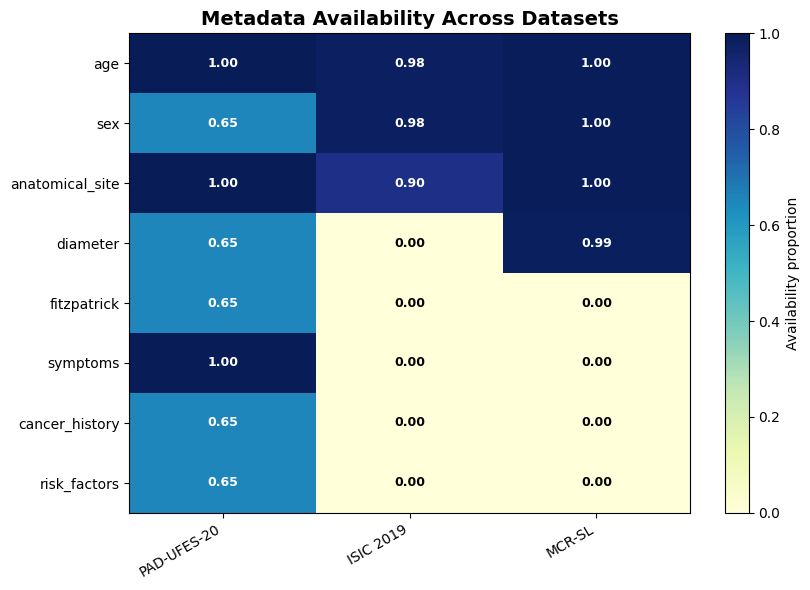

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\metadata_availability_heatmap_light.png
Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\example_image_grid_samples.csv


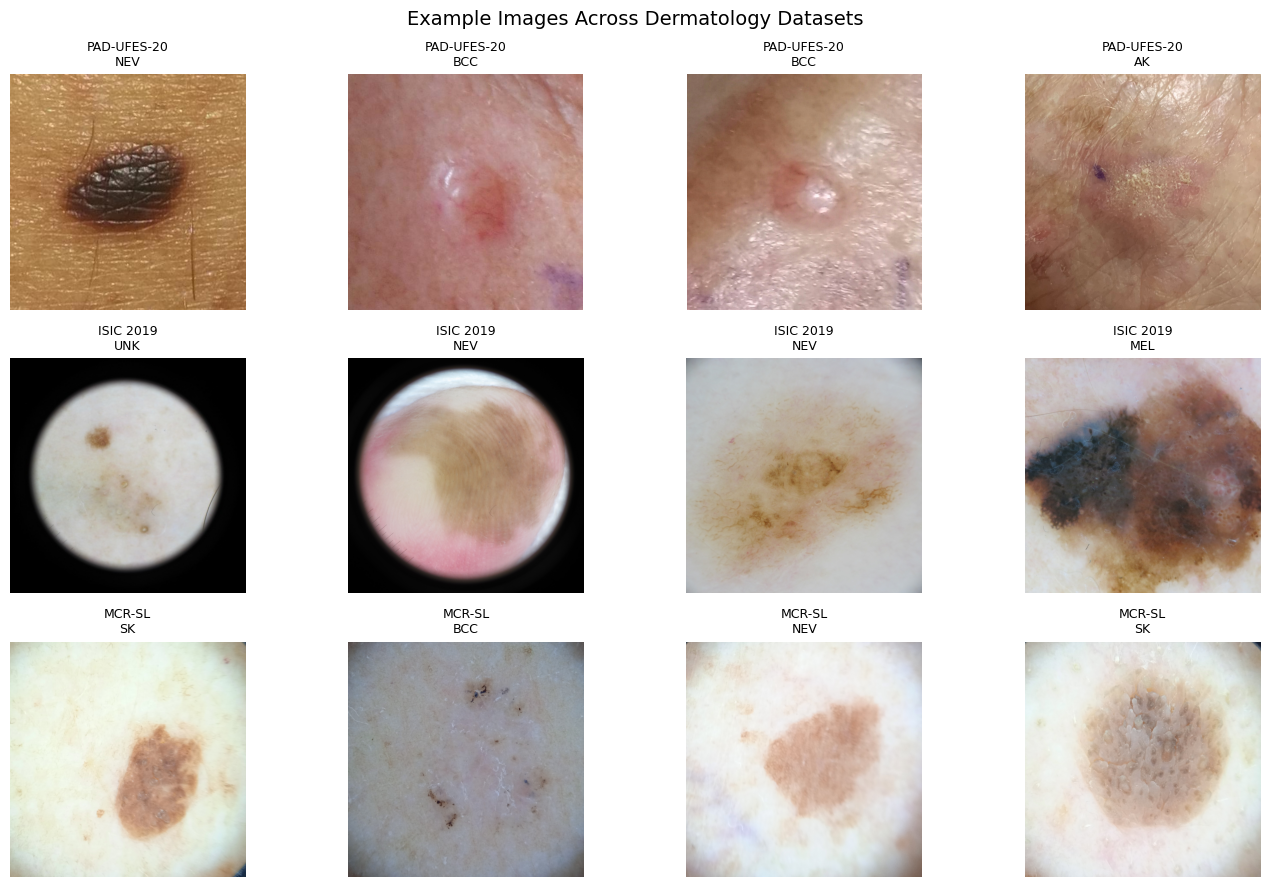

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\dataset_example_image_grid.png

KNOWN VS UNKNOWN TABLE


,Dataset,Known,Unknown / target-only
0,PAD-UFES-20,2298,0
1,ISIC 2019,30835,2734
2,MCR-SL,221,14


Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\known_vs_unknown_counts.csv


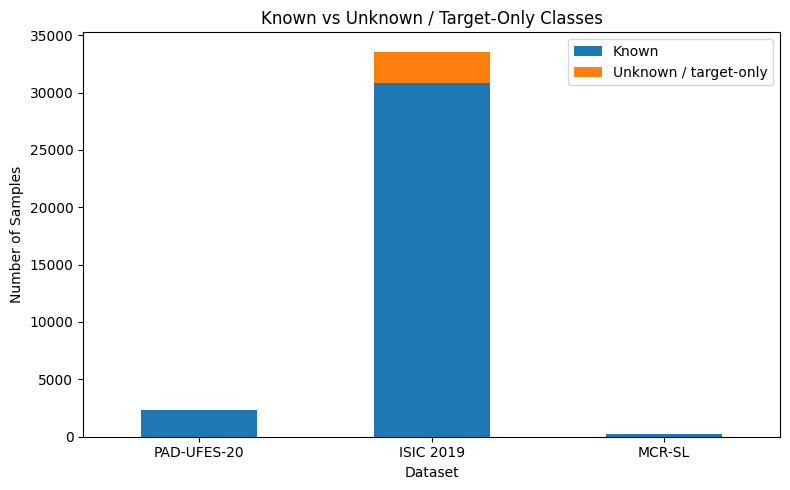

Saved: D:\Deep Learning\output\dataset_domain_shift_visuals\known_vs_unknown_counts.png

All dataset tables and visualizations saved to:
D:\Deep Learning\output\dataset_domain_shift_visuals


In [2]:
# ============================================================
# DATASET TABLE + VISUALIZATION BLOCK
# PAD-UFES, ISIC 2019, MCR-SL
# Outputs:
# 1. dataset comparison table
# 2. label overlap table
# 3. class distribution plots
# 4. metadata availability heatmap
# 5. example image grid
# ============================================================

from pathlib import Path
from PIL import Image

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

PADUFES_FILE = Path("D:/Deep Learning/metadata.csv")
PADUFES_IMAGE_DIR = Path("D:/Deep Learning/images")

STANDARDIZED_FILE = Path(
    "D:/Deep Learning/preprocessed_outputs/all_preprocessed_splits_standardized_text.csv"
)

MCR_IMAGE_ROOTS = [
    Path("D:/Deep Learning/MCR-SL_dataset/dermoscopic"),
    Path("D:/Deep Learning/MCR-SL_dataset/images"),
    Path("D:/Deep Learning/MCR-SL_dataset"),
]

ISIC_IMAGE_ROOTS = [
    Path(r"D:\Deep Learning\ISIC_2019_Training_Input"),
    Path(r"D:\Deep Learning\ISIC_2019_Test_Input"),
]

OUTPUT_DIR = Path("D:/Deep Learning/output/dataset_domain_shift_visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = ["", ".jpg", ".jpeg", ".png"]

KNOWN_CLASSES = ["AK", "BCC", "MEL", "NEV", "SCC", "SK"]

LABEL_MAP = {
    "ACK": "AK",
    "AK": "AK",
    "BCC": "BCC",
    "MEL": "MEL",
    "NEV": "NEV",
    "NV": "NEV",
    "SCC": "SCC",
    "SEK": "SK",
    "SK": "SK",
    "BKL": "SK",
    "DF": "DF",
    "VASC": "ANG",
    "ANG": "ANG",
    "ATY": "ATY",
    "UNK": "UNK",
}


# ============================================================
# BASIC FUNCTIONS
# ============================================================

def harmonize_label(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()
    x = x.replace("-", "_").replace("/", "_").replace(" ", "_")

    return LABEL_MAP.get(x, x)


def resolve_image_path(image_file, roots):
    image_file = str(image_file)

    for root in roots:
        for ext in IMAGE_EXTS:
            p = root / f"{image_file}{ext}"
            if p.exists():
                return str(p)

    return None


def resolve_padufes_image_path(image_file):
    image_file = str(image_file)

    candidates = [
        PADUFES_IMAGE_DIR / image_file,
        PADUFES_IMAGE_DIR / f"{image_file}.jpg",
        PADUFES_IMAGE_DIR / f"{image_file}.jpeg",
        PADUFES_IMAGE_DIR / f"{image_file}.png",
    ]

    for p in candidates:
        if p.exists():
            return str(p)

    return None


def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


# ============================================================
# LOAD DATA
# ============================================================

pad_raw = pd.read_csv(PADUFES_FILE)
all_std = pd.read_csv(STANDARDIZED_FILE, low_memory=False)

pad = pad_raw.copy()
pad["dataset"] = "PAD-UFES-20"
pad["label_harmonized"] = pad["diagnostic"].apply(harmonize_label)
pad["image_file"] = pad["img_id"].astype(str)
pad["image_path"] = pad["image_file"].apply(resolve_padufes_image_path)

isic = all_std[all_std["dataset"] == "ISIC 2019"].copy()
mcr = all_std[all_std["dataset"] == "MCR-SL"].copy()

isic["image_path"] = isic["image_file"].apply(
    lambda x: resolve_image_path(x, ISIC_IMAGE_ROOTS)
)

mcr["image_path"] = mcr["image_file"].apply(
    lambda x: resolve_image_path(x, MCR_IMAGE_ROOTS)
)

datasets = {
    "PAD-UFES-20": pad,
    "ISIC 2019": isic,
    "MCR-SL": mcr,
}


# ============================================================
# 1. DATASET COMPARISON TABLE
# ============================================================

comparison_rows = []

for name, df in datasets.items():
    labels = sorted(df["label_harmonized"].dropna().unique().tolist())

    known = sorted([x for x in labels if x in KNOWN_CLASSES])
    unknown = sorted([x for x in labels if x not in KNOWN_CLASSES])

    if name == "PAD-UFES-20":
        imaging_type = "Clinical smartphone"
        metadata_type = "Rich"
    elif name == "ISIC 2019":
        imaging_type = "Dermoscopic"
        metadata_type = "Limited / moderate"
    else:
        imaging_type = "Clinical / heterogeneous"
        metadata_type = "Sparse / heterogeneous"

    comparison_rows.append({
        "Dataset": name,
        "Total samples": len(df),
        "Available images": df["image_path"].notna().sum(),
        "Total classes": len(labels),
        "Known classes": ", ".join(known),
        "Unknown / target-only classes": ", ".join(unknown) if unknown else "None",
        "Metadata availability": metadata_type,
        "Imaging type": imaging_type,
    })

dataset_comparison_df = pd.DataFrame(comparison_rows)

print("\nDATASET COMPARISON TABLE")
display(dataset_comparison_df)

save_table(dataset_comparison_df, "dataset_comparison_table")


# ============================================================
# 2. LABEL OVERLAP TABLE
# ============================================================

all_labels = sorted(
    set(pad["label_harmonized"].dropna().unique())
    | set(isic["label_harmonized"].dropna().unique())
    | set(mcr["label_harmonized"].dropna().unique())
)

label_overlap_rows = []

for label in all_labels:
    label_overlap_rows.append({
        "Label": label,
        "PAD-UFES-20": "Yes" if label in set(pad["label_harmonized"]) else "No",
        "ISIC 2019": "Yes" if label in set(isic["label_harmonized"]) else "No",
        "MCR-SL": "Yes" if label in set(mcr["label_harmonized"]) else "No",
        "Known / Unknown": "Known" if label in KNOWN_CLASSES else "Unknown / target-only",
    })

label_overlap_df = pd.DataFrame(label_overlap_rows)

print("\nLABEL OVERLAP TABLE")
display(label_overlap_df)

save_table(label_overlap_df, "label_overlap_table")


# ============================================================
# 3. CLASS DISTRIBUTION BAR PLOTS
# ============================================================

class_count_rows = []

for name, df in datasets.items():
    counts = df["label_harmonized"].value_counts().sort_index()

    for label, count in counts.items():
        class_count_rows.append({
            "Dataset": name,
            "Label": label,
            "Count": count,
        })

class_counts_df = pd.DataFrame(class_count_rows)

save_table(class_counts_df, "class_distribution_counts")

# Combined bar plot with bold count labels
pivot_counts = class_counts_df.pivot(
    index="Label",
    columns="Dataset",
    values="Count"
).fillna(0)

ax = pivot_counts.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8
)

ax.set_title("Class Distribution Across Datasets", fontsize=14, fontweight="bold")
ax.set_xlabel("Harmonized Label", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Add bold numbers on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{int(v)}" if v > 0 else ""
            for v in container.datavalues
        ],
        padding=3,
        fontsize=8,
        fontweight="bold",
        rotation=90
    )

ax.legend(title="Dataset")
ax.margins(y=0.15)

plt.tight_layout()

class_plot_path = OUTPUT_DIR / "class_distribution_across_datasets_labeled.png"
plt.savefig(class_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {class_plot_path}")


# Individual plots
for name, df in datasets.items():
    counts = df["label_harmonized"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")

    plt.title(f"{name} Class Distribution")
    plt.xlabel("Harmonized Label")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    path = OUTPUT_DIR / f"{name.replace(' ', '_').replace('-', '_')}_class_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {path}")


# ============================================================
# 4. METADATA AVAILABILITY HEATMAP
# ============================================================

metadata_features = {
    "age": {
        "PAD-UFES-20": ["age"],
        "ISIC 2019": ["age_clean", "age_approx"],
        "MCR-SL": ["age_clean", "age"],
    },
    "sex": {
        "PAD-UFES-20": ["gender"],
        "ISIC 2019": ["sex_clean", "sex"],
        "MCR-SL": ["sex_clean", "sex"],
    },
    "anatomical_site": {
        "PAD-UFES-20": ["region"],
        "ISIC 2019": ["site_clean", "anatom_site_general"],
        "MCR-SL": ["site_clean", "location", "location_group"],
    },
    "diameter": {
        "PAD-UFES-20": ["diameter_1", "diameter_2"],
        "ISIC 2019": [],
        "MCR-SL": ["diameter_clean", "diameter"],
    },
    "fitzpatrick": {
        "PAD-UFES-20": ["fitspatrick"],
        "ISIC 2019": [],
        "MCR-SL": [],
    },
    "symptoms": {
        "PAD-UFES-20": ["itch", "grew", "hurt", "changed", "bleed", "elevation"],
        "ISIC 2019": [],
        "MCR-SL": [],
    },
    "cancer_history": {
        "PAD-UFES-20": ["skin_cancer_history", "cancer_history"],
        "ISIC 2019": [],
        "MCR-SL": [],
    },
    "risk_factors": {
        "PAD-UFES-20": ["smoke", "drink", "pesticide"],
        "ISIC 2019": [],
        "MCR-SL": [],
    },
}


def availability_score(df, cols):
    valid_cols = [c for c in cols if c in df.columns]

    if not valid_cols:
        return 0.0

    available = df[valid_cols].notna().any(axis=1).mean()

    return float(available)


availability_rows = []

for feature, mapping in metadata_features.items():
    row = {"Feature": feature}

    for dataset_name, df in datasets.items():
        cols = mapping.get(dataset_name, [])
        row[dataset_name] = availability_score(df, cols)

    availability_rows.append(row)

metadata_availability_df = pd.DataFrame(availability_rows)

print("\nMETADATA AVAILABILITY TABLE")
display(metadata_availability_df)

save_table(metadata_availability_df, "metadata_availability_table")

# Light-color metadata availability heatmap
heatmap_data = metadata_availability_df.set_index("Feature")

plt.figure(figsize=(8.5, 6))

im = plt.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label("Availability proportion", fontsize=10)

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns,
    rotation=30,
    ha="right",
    fontsize=10
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index,
    fontsize=10
)

plt.title(
    "Metadata Availability Across Datasets",
    fontsize=14,
    fontweight="bold"
)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.values[i, j]

        text_color = "black" if value < 0.65 else "white"

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

plt.tight_layout()

heatmap_path = OUTPUT_DIR / "metadata_availability_heatmap_light.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {heatmap_path}")

# ============================================================
# 5. IMAGE EXAMPLE GRID
# ============================================================

def sample_existing_images(df, n=4, seed=42):
    df = df[df["image_path"].notna()].copy()

    if len(df) == 0:
        return df

    return df.sample(
        n=min(n, len(df)),
        random_state=seed
    ).reset_index(drop=True)


example_rows = []

for name, df in datasets.items():
    sample_df = sample_existing_images(df, n=4, seed=42)

    for _, row in sample_df.iterrows():
        example_rows.append({
            "Dataset": name,
            "Label": row["label_harmonized"],
            "ImagePath": row["image_path"],
        })

example_df = pd.DataFrame(example_rows)

save_table(example_df, "example_image_grid_samples")

n_datasets = len(datasets)
n_examples = 4

fig, axes = plt.subplots(
    n_datasets,
    n_examples,
    figsize=(14, 9)
)

if n_datasets == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, dataset_name in enumerate(datasets.keys()):
    subset = example_df[example_df["Dataset"] == dataset_name].reset_index(drop=True)

    for col_idx in range(n_examples):
        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx >= len(subset):
            continue

        image_path = subset.loc[col_idx, "ImagePath"]
        label = subset.loc[col_idx, "Label"]

        try:
            img = Image.open(image_path).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{dataset_name}\n{label}", fontsize=9)
        except Exception as e:
            ax.set_title(f"{dataset_name}\nImage error", fontsize=9)

plt.suptitle("Example Images Across Dermatology Datasets", fontsize=14)
plt.tight_layout()

grid_path = OUTPUT_DIR / "dataset_example_image_grid.png"
plt.savefig(grid_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {grid_path}")


# ============================================================
# 6. KNOWN VS UNKNOWN CLASS COUNTS
# ============================================================

known_unknown_rows = []

for name, df in datasets.items():
    temp = df.copy()
    temp["known_unknown"] = np.where(
        temp["label_harmonized"].isin(KNOWN_CLASSES),
        "Known",
        "Unknown / target-only"
    )

    counts = temp["known_unknown"].value_counts()

    known_unknown_rows.append({
        "Dataset": name,
        "Known": counts.get("Known", 0),
        "Unknown / target-only": counts.get("Unknown / target-only", 0),
    })

known_unknown_df = pd.DataFrame(known_unknown_rows)

print("\nKNOWN VS UNKNOWN TABLE")
display(known_unknown_df)

save_table(known_unknown_df, "known_vs_unknown_counts")

plot_df = known_unknown_df.set_index("Dataset")

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("Known vs Unknown / Target-Only Classes")
ax.set_xlabel("Dataset")
ax.set_ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()

known_unknown_path = OUTPUT_DIR / "known_vs_unknown_counts.png"
plt.savefig(known_unknown_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {known_unknown_path}")


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nAll dataset tables and visualizations saved to:")
print(OUTPUT_DIR)

In [1]:
# ============================================================
# PAD-UFES ONLY CLOSED-SET BASELINE
# ResNet50 + BioClinicalBERT text fusion
# 3 text experiments + WeightedRandomSampler + extended metrics
# Confusion matrix, ROC curves, GradCAM++, and t-SNE outputs
# ============================================================

import os
import gc
import json
import random
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
from transformers import AutoModel, AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

from tqdm import tqdm

import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PADUFES_FILE = Path("D:/Deep Learning/metadata.csv")
PADUFES_IMAGE_DIR = Path("D:/Deep Learning/images")
RESULT_DIR = Path(r"D:\Deep Learning\output\crossattention_resnet50")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_NAME = "crossattention_resnet50"

IMAGE_MODEL_NAME = "resnet50"
TEXT_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

BATCH_SIZE = 32
NUM_WORKERS = 0

EPOCHS = 50
PATIENCE = 5

LR = 1e-4
WEIGHT_DECAY = 1e-4

MAX_TEXT_LEN = 96

BALANCE_BETA = 0.99

USE_SOFT_WEIGHTED_SAMPLER = True
USE_WEIGHTED_LOSS = True

FREEZE_BACKBONES = False

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]

# Saves plots by default. Set to True when running in a notebook and you also want them displayed inline.
SHOW_PLOTS = False

N_GRADCAM_EXAMPLES = 6

KNOWN_CLASSES = ["AK", "BCC", "MEL", "NEV", "SCC", "SK"]

LABEL_TO_ID = {label: idx for idx, label in enumerate(KNOWN_CLASSES)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}
NUM_CLASSES = len(KNOWN_CLASSES)

print("Device:", DEVICE)
print("Freeze backbones:", FREEZE_BACKBONES)
print("Text experiments:", TEXT_EXPERIMENTS)


# ============================================================
# LABEL HARMONIZATION
# ============================================================

LABEL_MAP = {
    "ACK": "AK",
    "AK": "AK",
    "BCC": "BCC",
    "MEL": "MEL",
    "NEV": "NEV",
    "NV": "NEV",
    "SCC": "SCC",
    "SEK": "SK",
    "SK": "SK",
    "BKL": "SK",
}


def harmonize_label(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()
    x = x.replace("-", "_").replace("/", "_").replace(" ", "_")

    return LABEL_MAP.get(x, x)


# ============================================================
# METADATA TEXTUALIZATION
# ============================================================

def is_missing(x):
    if pd.isna(x):
        return True

    x = str(x).strip().lower()

    return x in [
        "",
        "nan",
        "none",
        "null",
        "unknown",
        "unspecified",
        "na",
        "n/a",
    ]


def clean_text(x):
    if is_missing(x):
        return "unknown"

    return str(x).strip()


def clean_bool(x):
    if is_missing(x):
        return "unknown"

    x = str(x).strip().lower()

    if x in ["true", "1", "yes", "y"]:
        return "yes"

    if x in ["false", "0", "no", "n"]:
        return "no"

    return "unknown"


def clean_numeric(x, min_val=None, max_val=None):
    if is_missing(x):
        return "unknown"

    try:
        v = float(x)

        if min_val is not None and v < min_val:
            return "unknown"

        if max_val is not None and v > max_val:
            return "unknown"

        if v.is_integer():
            return str(int(v))

        return f"{v:.1f}"

    except Exception:
        return "unknown"


def standardize_location(x):
    if is_missing(x):
        return "unknown"

    x = str(x).strip().lower().replace("_", " ").replace("-", " ")

    mapping = {
        "face": "face",
        "scalp": "scalp",
        "ear": "ear",
        "neck": "neck",
        "head neck": "head or neck",
        "head/neck": "head or neck",
        "chest": "chest",
        "abdomen": "abdomen",
        "back": "back",
        "torso": "torso",
        "trunk": "torso",
        "arm": "upper limb",
        "forearm": "upper limb",
        "hand": "hand",
        "leg": "lower limb",
        "thigh": "lower limb",
        "foot": "foot",
    }

    return mapping.get(x, x)


def build_metadata_text(row):
    age = clean_numeric(
        row.get("age", np.nan),
        min_val=0,
        max_val=120
    )

    gender = clean_text(row.get("gender", np.nan)).lower()

    if gender in ["male", "m", "man"]:
        sex = "male"

    elif gender in ["female", "f", "woman"]:
        sex = "female"

    else:
        sex = "unknown"

    location = standardize_location(
        row.get("region", np.nan)
    )

    d1 = clean_numeric(
        row.get("diameter_1", np.nan),
        min_val=0,
        max_val=300
    )

    d2 = clean_numeric(
        row.get("diameter_2", np.nan),
        min_val=0,
        max_val=300
    )

    if d1 != "unknown" and d2 != "unknown":
        diameter = f"{d1} by {d2} mm"

    elif d1 != "unknown":
        diameter = f"{d1} mm"

    elif d2 != "unknown":
        diameter = f"{d2} mm"

    else:
        diameter = "unknown"

    meta = {
        "age": age,
        "sex": sex,
        "location": location,
        "diameter": diameter,
        "fitzpatrick": clean_numeric(row.get("fitspatrick", np.nan), min_val=1, max_val=6),

        "itch": clean_bool(row.get("itch", np.nan)),
        "grew": clean_bool(row.get("grew", np.nan)),
        "hurt": clean_bool(row.get("hurt", np.nan)),
        "changed": clean_bool(row.get("changed", np.nan)),
        "bleed": clean_bool(row.get("bleed", np.nan)),
        "elevation": clean_bool(row.get("elevation", np.nan)),

        "smoking": clean_bool(row.get("smoke", np.nan)),
        "alcohol": clean_bool(row.get("drink", np.nan)),
        "pesticide_exposure": clean_bool(row.get("pesticide", np.nan)),

        "personal_skin_cancer_history": clean_bool(row.get("skin_cancer_history", np.nan)),
        "general_cancer_history": clean_bool(row.get("cancer_history", np.nan)),
    }

    age_text = "an unknown age" if meta["age"] == "unknown" else f"{meta['age']} years old"
    sex_text = "unspecified biological sex" if meta["sex"] == "unknown" else meta["sex"]
    loc_text = "an unspecified anatomical location" if meta["location"] == "unknown" else meta["location"]

    text_core = (
        f"A clinical image of a skin lesion located on {loc_text} "
        f"from a patient who is {age_text} with {sex_text}."
    )

    text_full = (
        text_core + " "
        f"Diameter: {meta['diameter']}. "
        f"Fitzpatrick skin type: {meta['fitzpatrick']}. "
        f"Symptoms include itching: {meta['itch']}, growth: {meta['grew']}, pain: {meta['hurt']}, "
        f"change: {meta['changed']}, bleeding: {meta['bleed']}, elevation: {meta['elevation']}. "
        f"Smoking: {meta['smoking']}. Alcohol: {meta['alcohol']}. "
        f"Pesticide exposure: {meta['pesticide_exposure']}. "
        f"Personal skin cancer history: {meta['personal_skin_cancer_history']}. "
        f"General cancer history: {meta['general_cancer_history']}."
    )

    text_missing_explicit = text_core + " " + "; ".join(
        [f"{k}: {v}" for k, v in sorted(meta.items())]
    )

    return text_core, text_full, text_missing_explicit


# ============================================================
# LOAD PAD-UFES
# ============================================================

df = pd.read_csv(PADUFES_FILE)

df["label_harmonized"] = df["diagnostic"].apply(harmonize_label)

df = df[df["label_harmonized"].isin(KNOWN_CLASSES)].copy()

df["label_id"] = df["label_harmonized"].map(LABEL_TO_ID)

df["image_file"] = df["img_id"].astype(str)

texts = df.apply(build_metadata_text, axis=1)

df["text_core"] = [x[0] for x in texts]
df["text_full"] = [x[1] for x in texts]
df["text_missing_explicit"] = [x[2] for x in texts]

print("\nClass distribution:")
print(df["label_harmonized"].value_counts().sort_index())


# ============================================================
# IMAGE PATHS
# ============================================================

def resolve_padufes_image_path(image_file):
    candidates = [
        PADUFES_IMAGE_DIR / image_file,
        PADUFES_IMAGE_DIR / f"{image_file}.jpg",
        PADUFES_IMAGE_DIR / f"{image_file}.jpeg",
        PADUFES_IMAGE_DIR / f"{image_file}.png",
    ]

    for p in candidates:
        if p.exists():
            return str(p)

    return None


df["image_path"] = df["image_file"].apply(resolve_padufes_image_path)

missing = df["image_path"].isna().sum()

print("\nMissing images:", missing)

df = df[df["image_path"].notna()].reset_index(drop=True)


# ============================================================
# SPLIT: TRAIN / VAL / TEST = 70 / 15 / 15
# Same split is reused for all 3 text experiments.
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain class counts:")
print(train_df["label_harmonized"].value_counts().sort_index())

print("\nVal class counts:")
print(val_df["label_harmonized"].value_counts().sort_index())

print("\nTest class counts:")
print(test_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# TRANSFORMS + TOKENIZER
# ============================================================

from torchvision import transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),      
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(
        brightness=0.2,                       
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),         
    transforms.GaussianBlur(kernel_size=3,     
                            sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.1,            
                             scale=(0.02, 0.1))
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)


# ============================================================
# DATASET
# ============================================================

class PadUfesClosedSetDataset(Dataset):

    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }


# ============================================================
# WEIGHTED RANDOM SAMPLER
# ============================================================

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(train_df, beta=0.9):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights


# ============================================================
# MODEL
# ============================================================

class ResNet50Adapter(nn.Module):

    def __init__(self, model_name="resnet50"):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True
        )

        self.last_feature_map = None

    def forward(self, x):
        feats = self.backbone(x)

        last = feats[-1]

        self.last_feature_map = last
        if last.requires_grad:
            last.retain_grad()

        B, C, H, W = last.shape

        spatial = (
            last.reshape(B, C, H * W)
            .permute(0, 2, 1)
            .contiguous()
        )

        global_token = (
            last.mean(dim=(2, 3))
            .unsqueeze(1)
        )

        return torch.cat(
            [global_token, spatial],
            dim=1
        )


class ResNet50TextFusionClosedSet(nn.Module):

    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = ResNet50Adapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(fusion_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        return_features=False
    ):
        image_tokens = self.image_encoder(pixel_values)

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_tokens = text_out.last_hidden_state

        image_tokens = self.image_proj(image_tokens)
        text_tokens = self.text_proj(text_tokens)

        fused_tokens, _ = self.cross_attn(
            query=image_tokens,
            key=text_tokens,
            value=text_tokens,
            key_padding_mask=(attention_mask == 0)
        )

        fused_tokens = self.norm(fused_tokens + image_tokens)

        fused_cls = fused_tokens[:, 0, :]

        logits = self.classifier(fused_cls)

        if return_features:
            return logits, fused_cls

        return logits


# ============================================================
# UTILS
# ============================================================

def batch_to_device(batch):
    return {
        k: v.to(DEVICE)
        for k, v in batch.items()
        if torch.is_tensor(v)
    }


def maybe_show_or_close():
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()


def save_json(obj, path):
    cleaned = {}
    for k, v in obj.items():
        if isinstance(v, (np.floating, np.integer)):
            cleaned[k] = v.item()
        elif isinstance(v, float) and np.isnan(v):
            cleaned[k] = None
        else:
            cleaned[k] = v

    with open(path, "w", encoding="utf-8") as f:
        json.dump(cleaned, f, indent=2)


def tensor_to_display_image(tensor):
    # tensor shape: [3, H, W], normalized with ImageNet statistics
    x = tensor.detach().cpu().clone()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    x = x * std + mean
    x = x.clamp(0, 1)

    return x.permute(1, 2, 0).numpy()


# ============================================================
# METRICS
# ============================================================

def compute_multiclass_auc(y_true, y_prob):
    metrics = {}

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(NUM_CLASSES)),
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        metrics["macro_auc_ovr"] = np.nan

    try:
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(NUM_CLASSES)),
            multi_class="ovr",
            average="weighted"
        )
    except Exception:
        metrics["weighted_auc_ovr"] = np.nan

    y_bin = label_binarize(
        y_true,
        classes=list(range(NUM_CLASSES))
    )

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        try:
            if len(np.unique(y_bin[:, class_idx])) < 2:
                metrics[f"auc_{class_name}"] = np.nan
            else:
                metrics[f"auc_{class_name}"] = roc_auc_score(
                    y_bin[:, class_idx],
                    y_prob[:, class_idx]
                )
        except Exception:
            metrics[f"auc_{class_name}"] = np.nan

    return metrics


def compute_metrics(y_true, y_pred, y_prob, avg_loss):
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),

        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),

        "weighted_precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "weighted_recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

    metrics.update(
        compute_multiclass_auc(y_true, y_prob)
    )

    # Alias for the main AUC score.
    metrics["auc"] = metrics["macro_auc_ovr"]

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, name="EVAL", print_report=False, output_dir=None):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = batch_to_device(batch)

        logits = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        loss = criterion(
            logits,
            batch["label"]
        )

        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(
            batch["label"].detach().cpu().numpy()
        )

        all_pred.extend(
            preds.detach().cpu().numpy()
        )

        all_prob.append(
            probs.detach().cpu().numpy()
        )

    avg_loss = total_loss / max(len(loader), 1)

    y_true = np.asarray(all_true)
    y_pred = np.asarray(all_pred)
    y_prob = np.concatenate(all_prob, axis=0)

    metrics = compute_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        avg_loss=avg_loss
    )

    if print_report:
        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)
        print(f"Loss: {metrics['loss']:.4f}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision macro: {metrics['macro_precision']:.4f}")
        print(f"Recall macro: {metrics['macro_recall']:.4f}")
        print(f"F1 macro: {metrics['macro_f1']:.4f}")
        print(f"AUC macro OVR: {metrics['macro_auc_ovr']:.4f}")
        print(f"AUC weighted OVR: {metrics['weighted_auc_ovr']:.4f}")

        print("\nClassification report:")
        print(
            classification_report(
                y_true,
                y_pred,
                labels=list(range(NUM_CLASSES)),
                target_names=KNOWN_CLASSES,
                zero_division=0,
                digits=4
            )
        )

        if output_dir is not None:
            report_dict = classification_report(
                y_true,
                y_pred,
                labels=list(range(NUM_CLASSES)),
                target_names=KNOWN_CLASSES,
                zero_division=0,
                digits=4,
                output_dict=True
            )

            pd.DataFrame(report_dict).transpose().round(4).to_csv(
                output_dir / f"{name.lower().replace(' ', '_')}_classification_report.csv"
            )

            pd.DataFrame({
                "y_true": y_true,
                "y_pred": y_pred,
                **{
                    f"prob_{KNOWN_CLASSES[i]}": y_prob[:, i]
                    for i in range(NUM_CLASSES)
                }
            }).to_csv(
                output_dir / f"{name.lower().replace(' ', '_')}_predictions.csv",
                index=False
            )

    return metrics, y_true, y_pred, y_prob


# ============================================================
# PLOTS
# ============================================================

def plot_normalized_confusion_matrix(y_true, y_pred, output_path, title):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=KNOWN_CLASSES
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".4f",
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    maybe_show_or_close()


def plot_multiclass_roc(y_true, y_prob, output_path, title):
    y_bin = label_binarize(
        y_true,
        classes=list(range(NUM_CLASSES))
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        # ROC is undefined if this class has no positive or no negative samples.
        if len(np.unique(y_bin[:, class_idx])) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            y_bin[:, class_idx],
            y_prob[:, class_idx]
        )

        class_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_name} AUC={class_auc:.4f}"
        )

    try:
        fpr_micro, tpr_micro, _ = roc_curve(
            y_bin.ravel(),
            y_prob.ravel()
        )

        micro_auc = auc(fpr_micro, tpr_micro)

        ax.plot(
            fpr_micro,
            tpr_micro,
            linestyle="--",
            linewidth=2,
            label=f"micro-average AUC={micro_auc:.4f}"
        )
    except Exception:
        pass

    ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=650, bbox_inches="tight")
    maybe_show_or_close()


# ============================================================
# GRADCAM++
# ============================================================

def compute_gradcampp_from_feature_map(activations, gradients, eps=1e-8):
    """
    activations: [C, H, W]
    gradients:   [C, H, W]
    """
    grad_2 = gradients.pow(2)
    grad_3 = gradients.pow(3)

    spatial_sum = torch.sum(
        activations * grad_3,
        dim=(1, 2),
        keepdim=True
    )

    alpha = grad_2 / (2.0 * grad_2 + spatial_sum + eps)
    alpha = torch.where(
        torch.isfinite(alpha),
        alpha,
        torch.zeros_like(alpha)
    )

    weights = torch.sum(
        alpha * F.relu(gradients),
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * activations,
        dim=0
    )

    cam = F.relu(cam)

    cam_min = cam.min()
    cam_max = cam.max()

    if (cam_max - cam_min) > eps:
        cam = (cam - cam_min) / (cam_max - cam_min + eps)
    else:
        cam = torch.zeros_like(cam)

    return cam


def generate_gradcampp_examples(model, dataset, output_dir, n_examples=6):
    output_dir.mkdir(exist_ok=True, parents=True)

    model.eval()

    # Pick diverse examples: first available test image from each class.
    selected_indices = []
    labels = dataset.df["label_id"].to_numpy()

    for class_idx in range(NUM_CLASSES):
        idxs = np.where(labels == class_idx)[0]
        if len(idxs) > 0:
            selected_indices.append(int(idxs[0]))

    selected_indices = selected_indices[:n_examples]

    saved = 0

    for dataset_idx in selected_indices:
        sample = dataset[dataset_idx]

        pixel_values = sample["pixel_values"].unsqueeze(0).to(DEVICE)
        pixel_values.requires_grad_(True)

        input_ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)
        true_label = int(sample["label"].item())

        model.zero_grad(set_to_none=True)

        logits = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(logits, dim=1)
        pred_label = int(torch.argmax(probs, dim=1).item())

        target_score = logits[0, pred_label]
        target_score.backward(retain_graph=True)

        feature_map = model.image_encoder.last_feature_map

        if feature_map is None or feature_map.grad is None:
            print("Skipping GradCAM++ example because gradients were unavailable.")
            continue

        activations = feature_map.detach()[0]
        gradients = feature_map.grad.detach()[0]

        cam = compute_gradcampp_from_feature_map(
            activations=activations,
            gradients=gradients
        )

        cam = F.interpolate(
            cam[None, None, :, :],
            size=pixel_values.shape[-2:],
            mode="bilinear",
            align_corners=False
        )[0, 0]

        cam_np = cam.detach().cpu().numpy()
        image_np = tensor_to_display_image(sample["pixel_values"])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np)
        plt.imshow(cam_np, cmap="jet", alpha=0.45)
        plt.axis("off")

        plt.title(
            f"True: {ID_TO_LABEL[true_label]} | "
            f"Pred: {ID_TO_LABEL[pred_label]} | "
            f"P={probs[0, pred_label].item():.4f}"
        )

        out_path = output_dir / (
            f"gradcampp_{saved:02d}_"
            f"true_{ID_TO_LABEL[true_label]}_"
            f"pred_{ID_TO_LABEL[pred_label]}.png"
        )

        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        maybe_show_or_close()

        saved += 1

    print(f"Saved {saved} GradCAM++ examples to: {output_dir}")


# ============================================================
# T-SNE
# ============================================================

@torch.no_grad()
def extract_fused_features(model, loader):
    model.eval()

    all_features = []
    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc="Extracting fused features", leave=False):
        batch = batch_to_device(batch)

        logits, fused_features = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            return_features=True
        )

        preds = logits.argmax(dim=1)

        all_features.append(
            fused_features.detach().cpu().numpy()
        )

        all_true.extend(
            batch["label"].detach().cpu().numpy()
        )

        all_pred.extend(
            preds.detach().cpu().numpy()
        )

    return (
        np.concatenate(all_features, axis=0),
        np.asarray(all_true),
        np.asarray(all_pred)
    )


def plot_tsne(model, loader, output_dir, title):
    features, y_true, y_pred = extract_fused_features(
        model,
        loader
    )

    n_samples = features.shape[0]

    if n_samples < 3:
        print("Skipping t-SNE because there are fewer than 3 samples.")
        return

    perplexity = min(30, max(2, (n_samples - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED
    )

    emb = tsne.fit_transform(features)

    tsne_df = pd.DataFrame({
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "true_label_id": y_true,
        "true_label": [ID_TO_LABEL[int(x)] for x in y_true],
        "pred_label_id": y_pred,
        "pred_label": [ID_TO_LABEL[int(x)] for x in y_pred],
    })

    tsne_df.to_csv(
        output_dir / "test_tsne_coordinates.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        mask = y_true == class_idx

        if mask.sum() == 0:
            continue

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            s=35,
            alpha=0.8,
            label=class_name
        )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(title="True class", fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        output_dir / "test_tsne_true_labels.png",
        dpi=300,
        bbox_inches="tight"
    )
    maybe_show_or_close()

    fig, ax = plt.subplots(figsize=(8, 7))

    correct = y_true == y_pred

    ax.scatter(
        emb[correct, 0],
        emb[correct, 1],
        s=35,
        alpha=0.8,
        label="correct"
    )

    ax.scatter(
        emb[~correct, 0],
        emb[~correct, 1],
        s=35,
        alpha=0.8,
        label="incorrect"
    )

    ax.set_title(title + " correctness")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        output_dir / "test_tsne_correct_vs_incorrect.png",
        dpi=300,
        bbox_inches="tight"
    )
    maybe_show_or_close()


# ============================================================
# EXPERIMENT RUNNER
# ============================================================

def build_loaders_for_text_col(text_col):
    train_ds = PadUfesClosedSetDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col
    )

    val_ds = PadUfesClosedSetDataset(
        val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    test_ds = PadUfesClosedSetDataset(
        test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    train_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    train_eval_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda")
    )

    return train_loader, train_eval_loader, val_loader, test_loader, test_ds


train_loader, train_eval_loader, val_loader, test_loader, test_ds = build_loaders_for_text_col(TEXT_EXPERIMENTS[0])

from collections import Counter

def print_loader_dataset_counts(name, loader):
    # Fast: read labels directly from the dataset dataframe.
    # This avoids loading/augmenting every image just to count labels.
    labels = loader.dataset.df["label_id"].astype(int).to_numpy()

    counts = Counter(labels)
    total = sum(counts.values())

    print(f"\n=== {name} Set Class Distribution ===")
    for cls_id in range(NUM_CLASSES):
        count = counts.get(cls_id, 0)
        pct = 100 * count / total if total > 0 else 0
        bar = "█" * int(40 * count / total) if total > 0 else ""
        print(f"{ID_TO_LABEL[cls_id]:>3} / Class {cls_id}: {count:>5} ({pct:>5.1f}%)  {bar}")

    if counts:
        max_count = max(counts.values())
        min_count = min(counts.values())
        print(f"\nTotal samples   : {total}")
        print(f"Num classes     : {len(counts)}")
        print(f"Imbalance ratio : {max_count / min_count:.1f}x")


print_loader_dataset_counts("Training", train_loader)
print_loader_dataset_counts("Validation", val_loader)
print_loader_dataset_counts("Test", test_loader)


def run_single_experiment(text_col):
    print("\n" + "#" * 80)
    print(f"STARTING EXPERIMENT: {text_col}")
    print("#" * 80)


    experiment_dir = RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)
    
    best_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    final_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_final.pt"
    (
        train_loader,
        train_eval_loader,
        val_loader,
        test_loader,
        test_ds
    ) = build_loaders_for_text_col(text_col)

    model = ResNet50TextFusionClosedSet(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    # WeightedRandomSampler already balances the batches.
    # Avoid using class-weighted CE simultaneously unless you intentionally want stronger minority weighting.
    if USE_WEIGHTED_LOSS:
        loss_weights = get_loss_weights_from_train_df(
            train_df,
            beta=BALANCE_BETA,
            device=DEVICE
        )
    
        criterion = nn.CrossEntropyLoss(
            weight=loss_weights
        )
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=3,
        factor=0.5
    )

    best_val_f1 = -np.inf
    early_count = 0

    best_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    final_model_path = experiment_dir / f"{MODEL_SAVE_NAME}_{text_col}_final.pt"

    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()

        running_loss = 0.0

        pbar = tqdm(
            train_loader,
            desc=f"{text_col} | Epoch {epoch}/{EPOCHS}"
        )

        for batch in pbar:
            batch = batch_to_device(batch)

            optimizer.zero_grad(set_to_none=True)

            logits = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            loss = criterion(
                logits,
                batch["label"]
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pbar.set_postfix(
                {
                    "loss": f"{running_loss / (pbar.n + 1):.4f}"
                }
            )

        train_metrics, _, _, _ = evaluate(
            model,
            train_eval_loader,
            criterion,
            name=f"{text_col} TRAIN EPOCH {epoch}",
            print_report=False
        )

        val_metrics, _, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            name=f"{text_col} VAL EPOCH {epoch}",
            print_report=False
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"\n{text_col} | Epoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Train Loss={train_metrics['loss']:.4f}, "
            f"Train Acc={train_metrics['accuracy']:.4f}, "
            f"Train Macro-F1={train_metrics['macro_f1']:.4f}, "
            f"Train AUC={train_metrics['auc']:.4f} | "
            f"Val Loss={val_metrics['loss']:.4f}, "
            f"Val Acc={val_metrics['accuracy']:.4f}, "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f}, "
            f"Val AUC={val_metrics['auc']:.4f}"
        )

        history_row = {
            "epoch": epoch,
            "lr": current_lr,
        }

        for k, v in train_metrics.items():
            history_row[f"train_{k}"] = v

        for k, v in val_metrics.items():
            history_row[f"val_{k}"] = v

        history.append(history_row)

        pd.DataFrame(history).to_csv(
            experiment_dir / f"padufes_closed_set_{text_col}_history.csv",
            index=False
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )


            print(
                f"Saved best model with val Macro-F1: {best_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= PATIENCE:
                print("Early stopping.")
                break

    # ========================================================
    # FINAL TEST EVALUATION
    # ========================================================

    model.load_state_dict(
        torch.load(best_model_path, map_location=DEVICE)
    )

    test_metrics, y_true, y_pred, y_prob = evaluate(
        model,
        test_loader,
        criterion,
        name=f"{text_col} FINAL TEST",
        print_report=True,
        output_dir=experiment_dir
    )

    torch.save(
        model.state_dict(),
        final_model_path
    )

    save_json(
        {
            "text_col": text_col,
            "best_val_macro_f1": best_val_f1,
            **test_metrics,
        },
        experiment_dir / f"padufes_closed_set_{text_col}_test_metrics.json"
    )

    plot_normalized_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        output_path=experiment_dir / "normalized_confusion_matrix_resnet50CrossAttention.png",
        title=f"{text_col} normalized confusion matrix"
    )

    plot_multiclass_roc(
        y_true=y_true,
        y_prob=y_prob,
        output_path=experiment_dir / "multiclass_roc_curve_resnet50CrossAttention.png",
        title=f"{text_col} multiclass ROC curve"
    )

    generate_gradcampp_examples(
        model=model,
        dataset=test_ds,
        output_dir=experiment_dir / "gradcampp_resnet50CrossAttention",
        n_examples=N_GRADCAM_EXAMPLES
    )

    plot_tsne(
        model=model,
        loader=test_loader,
        output_dir=experiment_dir,
        title=f"{text_col} test fused-feature t-SNE"
    )

    print("\nFinished experiment:", text_col)
    print("Best validation Macro-F1:", best_val_f1)
    print("Final test metrics:", test_metrics)

    result_row = {
        "text_col": text_col,
        "best_val_macro_f1": best_val_f1,
        **test_metrics
    }

    # Clear memory before next experiment.
    del model
    del optimizer
    del scheduler
    del train_loader
    del train_eval_loader
    del val_loader
    del test_loader
    del test_ds

    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return result_row

Device: cuda
Freeze backbones: False
Text experiments: ['text_full', 'text_core', 'text_missing_explicit']

Class distribution:
label_harmonized
AK     730
BCC    845
MEL     52
NEV    244
SCC    192
SK     235
Name: count, dtype: int64

Missing images: 0

Split sizes:
Train: (1608, 33)
Val: (345, 33)
Test: (345, 33)

Train class counts:
label_harmonized
AK     511
BCC    591
MEL     36
NEV    171
SCC    134
SK     165
Name: count, dtype: int64

Val class counts:
label_harmonized
AK     109
BCC    127
MEL      8
NEV     37
SCC     29
SK      35
Name: count, dtype: int64

Test class counts:
label_harmonized
AK     110
BCC    127
MEL      8
NEV     36
SCC     29
SK      35
Name: count, dtype: int64



=== Training Set Class Distribution ===
 AK / Class 0:   511 ( 31.8%)  ████████████
BCC / Class 1:   591 ( 36.8%)  ██████████████
MEL / Class 2:    36 (  2.2%)  
NEV / Class 3:   171 ( 10.6%)  ████
SCC / Class 4:   134 (  8.3%)  ███
 SK / Class 5:   165 ( 10.3%)  ████

Total samples   : 1608
Num classes     : 6
Imbalance ratio : 16.4x

=== Validation Set Class Distribution ===
 AK / Class 0:   109 ( 31.6%)  ████████████
BCC / Class 1:   127 ( 36.8%)  ██████████████
MEL / Class 2:     8 (  2.3%)  
NEV / Class 3:    37 ( 10.7%)  ████
SCC / Class 4:    29 (  8.4%)  ███
 SK / Class 5:    35 ( 10.1%)  ████

Total samples   : 345
Num classes     : 6
Imbalance ratio : 15.9x

=== Test Set Class Distribution ===
 AK / Class 0:   110 ( 31.9%)  ████████████
BCC / Class 1:   127 ( 36.8%)  ██████████████
MEL / Class 2:     8 (  2.3%)  
NEV / Class 3:    36 ( 10.4%)  ████
SCC / Class 4:    29 (  8.4%)  ███
 SK / Class 5:    35 ( 10.1%)  ████

Total samples   : 345
Num classes     : 6
Imbalance rati

In [2]:
# ============================================================
# RUN ALL THREE EXPERIMENTS
# ============================================================

all_results = []

for text_col in TEXT_EXPERIMENTS:
    result_row = run_single_experiment(text_col)
    all_results.append(result_row)

summary_df = pd.DataFrame(all_results)
summary_path = RESULT_DIR / "padufes_closed_set_all_text_experiments_summary_resnet50CrossAttention.csv"
summary_df.round(4).to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 80)
print(summary_df.round(4))
print("\nSaved summary to:", summary_path)


################################################################################
STARTING EXPERIMENT: text_full
################################################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Class weights for loss:
  AK: 0.6627
  BCC: 0.6605
  MEL: 2.1700
  NEV: 0.8027
  SCC: 0.8903
  SK: 0.8138


text_full | Epoch 1/50: 100%|██████████| 51/51 [00:55<00:00,  1.10s/it, loss=1.5167]
                                                                                   

...


text_missing_explicit | Epoch 18 Summary | LR=5.00e-05 | Train Loss=0.6197, Train Acc=0.7662, Train Macro-F1=0.7402, Train AUC=0.9538 | Val Loss=0.7541, Val Acc=0.6841, Val Macro-F1=0.6328, Val AUC=0.9228


text_missing_explicit | Epoch 19/50: 100%|██████████| 51/51 [00:51<00:00,  1.01s/it, loss=0.5816]
                                                                                                


text_missing_explicit | Epoch 19 Summary | LR=5.00e-05 | Train Loss=0.5084, Train Acc=0.8035, Train Macro-F1=0.7704, Train AUC=0.9622 | Val Loss=0.6669, Val Acc=0.7333, Val Macro-F1=0.6656, Val AUC=0.9304
Early stopping.



text_missing_explicit FINAL TEST
Loss: 0.7294
Accuracy: 0.7449
Precision macro: 0.6589
Recall macro: 0.6380
F1 macro: 0.6426
AUC macro OVR: 0.9376
AUC weighted OVR: 0.9338

Classification report:
              precision    recall  f1-score   support

          AK     0.9250    0.6727    0.7789       110
         BCC     0.7469    0.9528    0.8374       127
         MEL     0.5000    0.5000    0.5000         8
         NEV     0.6944    0.6944    0.6944        36
         SCC     0.4400    0.3793    0.4074        29
          SK     0.6471    0.6286    0.6377        35

    accuracy                         0.7449       345
   macro avg     0.6589    0.6380    0.6426       345
weighted avg     0.7566    0.7449    0.7396       345

Saved 6 GradCAM++ examples to: D:\Deep Learning\output\crossattention_resnet50\text_missing_explicit\gradcampp_resnet50CrossAttention



Finished experiment: text_missing_explicit
Best validation Macro-F1: 0.6740386796353306
Final test metrics: {'loss': 0.7294382967732169, 'accuracy': 0.744927536231884, 'macro_precision': 0.658902808036795, 'macro_recall': 0.6379682326804239, 'macro_f1': 0.6426417703179546, 'weighted_precision': 0.7565654594634418, 'weighted_recall': 0.744927536231884, 'weighted_f1': 0.7396054686437287, 'macro_auc_ovr': 0.9375653155885817, 'weighted_auc_ovr': 0.9337552310648682, 'auc_AK': 0.9418181818181818, 'auc_BCC': 0.9277252040742614, 'auc_MEL': 0.9840504451038576, 'auc_NEV': 0.9715929521754765, 'auc_SCC': 0.8554124836316019, 'auc_SK': 0.9447926267281106, 'auc': 0.9375653155885817}

ALL EXPERIMENTS COMPLETE
                text_col  best_val_macro_f1    loss  accuracy  \
0              text_full             0.7410  0.7732    0.7246   
1              text_core             0.6841  0.8206    0.6580   
2  text_missing_explicit             0.6740  0.7294    0.7449   

   macro_precision  macro_recall  m

<h1>Directly Evaluating on Closed-set of MCR Dataset</h1>

In [3]:
# ============================================================
# DIRECT MCR EVALUATION FOR ALL SAVED PAD-UFES MODELS
# text_full, text_core, text_missing_explicit
# No DANN adaptation here
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


PAD_MODEL_ROOT = Path(r"D:\Deep Learning\output\crossattention_resnet50")

MCR_DIRECT_RESULT_DIR = Path(r"D:\Deep Learning\output\crossattention_resnet50\mcr_direct_transfer")
MCR_DIRECT_RESULT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = len(KNOWN_CLASSES)
LABEL_IDS = list(range(NUM_CLASSES))

eval_criterion = nn.CrossEntropyLoss()


# ============================================================
# CREATE MCR KNOWN-ONLY DATAFRAMES
# Run this BEFORE make_mcr_loaders_for_text()
# ============================================================

MCR_STANDARDIZED_FILE = Path(
    "D:/Deep Learning/preprocessed_outputs/all_preprocessed_splits_standardized_text.csv"
)

MCR_IMAGE_ROOTS = [
    Path("D:/Deep Learning/MCR-SL_dataset/dermoscopic"),
    Path("D:/Deep Learning/MCR-SL_dataset/images"),
    Path("D:/Deep Learning/MCR-SL_dataset"),
]

IMAGE_EXTS = ["", ".jpg", ".jpeg", ".png"]

mcr_df = pd.read_csv(MCR_STANDARDIZED_FILE, low_memory=False)

mcr_known_df = mcr_df[
    (mcr_df["dataset"] == "MCR-SL") &
    (mcr_df["label_harmonized"].isin(KNOWN_CLASSES))
].copy()

mcr_known_df["label_id"] = mcr_known_df["label_harmonized"].map(LABEL_TO_ID)

mcr_adapt_df = mcr_known_df[
    mcr_known_df["split"] == "target_adapt"
].reset_index(drop=True)

mcr_val_df = mcr_known_df[
    mcr_known_df["split"] == "target_val"
].reset_index(drop=True)

mcr_test_df = mcr_known_df[
    mcr_known_df["split"] == "target_test"
].reset_index(drop=True)


def resolve_mcr_image_path(image_file):
    image_file = str(image_file)

    for root in MCR_IMAGE_ROOTS:
        for ext in IMAGE_EXTS:
            path = root / f"{image_file}{ext}"
            if path.exists():
                return str(path)

    return None


for d in [mcr_adapt_df, mcr_val_df, mcr_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_mcr_image_path)

print("Missing MCR adapt images:", mcr_adapt_df["image_path"].isna().sum())
print("Missing MCR val images:", mcr_val_df["image_path"].isna().sum())
print("Missing MCR test images:", mcr_test_df["image_path"].isna().sum())

mcr_adapt_df = mcr_adapt_df[mcr_adapt_df["image_path"].notna()].reset_index(drop=True)
mcr_val_df = mcr_val_df[mcr_val_df["image_path"].notna()].reset_index(drop=True)
mcr_test_df = mcr_test_df[mcr_test_df["image_path"].notna()].reset_index(drop=True)

print("\nMCR adapt:")
print(mcr_adapt_df["label_harmonized"].value_counts().sort_index())

print("\nMCR val:")
print(mcr_val_df["label_harmonized"].value_counts().sort_index())

print("\nMCR test:")
print(mcr_test_df["label_harmonized"].value_counts().sort_index())

# ============================================================
# MCR KNOWN-ONLY DATASET
# Run this BEFORE make_mcr_loaders_for_text()
# ============================================================

class MCRKnownOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label=None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        item = {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }

        if self.domain_label is not None:
            item["domain"] = torch.tensor(self.domain_label, dtype=torch.long)

        return item

def make_mcr_loaders_for_text(text_col):
    assert text_col in mcr_val_df.columns, f"{text_col} not found in mcr_val_df"
    assert text_col in mcr_test_df.columns, f"{text_col} not found in mcr_test_df"

    mcr_val_ds = MCRKnownOnlyDataset(
        mcr_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=None
    )

    mcr_test_ds = MCRKnownOnlyDataset(
        mcr_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=None
    )

    mcr_val_loader = DataLoader(
        mcr_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_test_loader = DataLoader(
        mcr_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    return mcr_val_loader, mcr_test_loader


@torch.no_grad()
def evaluate_direct_model_on_mcr(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = {
            k: v.to(DEVICE) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        logits = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        loss = eval_criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    macro_f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_f1 = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    try:
        macro_auc_ovr = roc_auc_score(
            y_true,
            y_prob,
            labels=LABEL_IDS,
            multi_class="ovr",
            average="macro"
        )

        weighted_auc_ovr = roc_auc_score(
            y_true,
            y_prob,
            labels=LABEL_IDS,
            multi_class="ovr",
            average="weighted"
        )

    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        macro_auc_ovr = np.nan
        weighted_auc_ovr = np.nan

    per_class_auc = {}

    y_true_bin = label_binarize(
        y_true,
        classes=LABEL_IDS
    )

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        try:
            if len(np.unique(y_true_bin[:, class_idx])) < 2:
                per_class_auc[f"auc_{class_name}"] = np.nan
            else:
                per_class_auc[f"auc_{class_name}"] = roc_auc_score(
                    y_true_bin[:, class_idx],
                    y_prob[:, class_idx]
                )
        except Exception:
            per_class_auc[f"auc_{class_name}"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall: {weighted_recall:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Macro AUC OVR: {macro_auc_ovr:.4f}")
    print(f"Weighted AUC OVR: {weighted_auc_ovr:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=LABEL_IDS,
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "true_label": [KNOWN_CLASSES[i] for i in y_true],
        "pred_label": [KNOWN_CLASSES[i] for i in y_pred],
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_predictions.csv",
        index=False
    )

    # Normalized confusion matrix
    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )
    ax.set_title(f"{text_col} - {split_name} normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_normalized_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    # ROC curve
    fig, ax = plt.subplots(figsize=(8, 7))

    for class_idx, class_name in enumerate(KNOWN_CLASSES):
        if len(np.unique(y_true_bin[:, class_idx])) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, class_idx],
            y_prob[:, class_idx]
        )

        class_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            label=f"{class_name} AUC={class_auc:.4f}"
        )

    ax.plot([0, 1], [0, 1], "--", label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{text_col} - {split_name} ROC curve")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_roc_curve.png",
        dpi=300
    )
    plt.close()

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "macro_auc_ovr": macro_auc_ovr,
        "weighted_auc_ovr": weighted_auc_ovr,
    }

    metrics.update(per_class_auc)

    return metrics


# ============================================================
# LOAD EACH SAVED MODEL AND EVALUATE ON MCR
# ============================================================

all_mcr_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING MCR DIRECT EVALUATION: {text_col}")
    print("#" * 80)

    experiment_output_dir = MCR_DIRECT_RESULT_DIR / text_col
    experiment_output_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    print("Loading model:", checkpoint_path)

    model = ResNet50TextFusionClosedSet(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE)
    )

    mcr_val_loader, mcr_test_loader = make_mcr_loaders_for_text(
        text_col
    )

    val_metrics = evaluate_direct_model_on_mcr(
        model=model,
        loader=mcr_val_loader,
        name=f"{text_col}: PAD-UFES → MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="val",
        output_dir=experiment_output_dir
    )

    test_metrics = evaluate_direct_model_on_mcr(
        model=model,
        loader=mcr_test_loader,
        name=f"{text_col}: PAD-UFES → MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="test",
        output_dir=experiment_output_dir
    )

    all_mcr_results.append(val_metrics)
    all_mcr_results.append(test_metrics)

    del model
    torch.cuda.empty_cache()


summary_df = pd.DataFrame(all_mcr_results)

summary_path = MCR_DIRECT_RESULT_DIR / "mcr_direct_transfer_all_text_experiments_summary.csv"

summary_df.round(4).to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 80)
print("MCR DIRECT TRANSFER SUMMARY")
print("=" * 80)
print(summary_df.round(4))
print("\nSaved summary to:", summary_path)

Missing MCR adapt images: 2
Missing MCR val images: 1
Missing MCR test images: 1

MCR adapt:
label_harmonized
AK      6
BCC    18
MEL     5
NEV    50
SCC     2
SK     49
Name: count, dtype: int64

MCR val:
label_harmonized
AK      2
BCC     6
MEL     2
NEV    16
SCC     1
SK     16
Name: count, dtype: int64

MCR test:
label_harmonized
AK      2
BCC     6
MEL     1
NEV    17
SCC     1
SK     17
Name: count, dtype: int64

################################################################################
STARTING MCR DIRECT EVALUATION: text_full
################################################################################
Loading model: D:\Deep Learning\output\crossattention_resnet50\text_full\crossattention_resnet50_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                  


text_full: PAD-UFES → MCR KNOWN-ONLY VAL
Loss: 2.4683
Accuracy: 0.4186
Macro Precision: 0.1905
Macro Recall: 0.2604
Macro F1: 0.1967
Weighted Precision: 0.3787
Weighted Recall: 0.4186
Weighted F1: 0.3669
Macro AUC OVR: 0.7468
Weighted AUC OVR: 0.6926

Classification report:
              precision    recall  f1-score   support

          AK     0.1429    0.5000    0.2222         2
         BCC     0.0000    0.0000    0.0000         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.5556    0.3125    0.4000        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.4444    0.7500    0.5581        16

    accuracy                         0.4186        43
   macro avg     0.1905    0.2604    0.1967        43
weighted avg     0.3787    0.4186    0.3669        43




text_full: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.8653
Accuracy: 0.5682
Macro Precision: 0.2609
Macro Recall: 0.3922
Macro F1: 0.2899
Weighted Precision: 0.5073
Weighted Recall: 0.5682
Weighted F1: 0.5206
Macro AUC OVR: 0.8088
Weighted AUC OVR: 0.7996

Classification report:
              precision    recall  f1-score   support

          AK     0.2857    1.0000    0.4444         2
         BCC     0.0000    0.0000    0.0000         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.7143    0.5882    0.6452        17
         SCC     0.0000    0.0000    0.0000         1
          SK     0.5652    0.7647    0.6500        17

    accuracy                         0.5682        44
   macro avg     0.2609    0.3922    0.2899        44
weighted avg     0.5073    0.5682    0.5206        44


################################################################################
STARTING MCR DIRECT EVALUATION: text_core
########################################################

...


text_core: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.1365
Accuracy: 0.5455
Macro Precision: 0.5297
Macro Recall: 0.5196
Macro F1: 0.4256
Weighted Precision: 0.7326
Weighted Recall: 0.5455
Weighted F1: 0.5482
Macro AUC OVR: 0.9164
Weighted AUC OVR: 0.8661

Classification report:
              precision    recall  f1-score   support

          AK     1.0000    0.5000    0.6667         2
         BCC     0.3750    0.5000    0.4286         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.6364    0.8235    0.7179        17
         SCC     0.1667    1.0000    0.2857         1
          SK     1.0000    0.2941    0.4545        17

    accuracy                         0.5455        44
   macro avg     0.5297    0.5196    0.4256        44
weighted avg     0.7326    0.5455    0.5482        44


################################################################################
STARTING MCR DIRECT EVALUATION: text_missing_explicit
############################################

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                              


text_missing_explicit: PAD-UFES → MCR KNOWN-ONLY VAL
Loss: 1.5613
Accuracy: 0.3953
Macro Precision: 0.2500
Macro Recall: 0.3368
Macro F1: 0.2576
Weighted Precision: 0.3666
Weighted Recall: 0.3953
Weighted F1: 0.3287
Macro AUC OVR: 0.7857
Weighted AUC OVR: 0.6985

Classification report:
              precision    recall  f1-score   support

          AK     0.3333    0.5000    0.4000         2
         BCC     0.3571    0.8333    0.5000         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.4762    0.6250    0.5405        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.3333    0.0625    0.1053        16

    accuracy                         0.3953        43
   macro avg     0.2500    0.3368    0.2576        43
weighted avg     0.3666    0.3953    0.3287        43




text_missing_explicit: PAD-UFES → MCR KNOWN-ONLY TEST
Loss: 1.2466
Accuracy: 0.5682
Macro Precision: 0.4444
Macro Recall: 0.4085
Macro F1: 0.3949
Weighted Precision: 0.5852
Weighted Recall: 0.5682
Weighted F1: 0.5493
Macro AUC OVR: 0.8878
Weighted AUC OVR: 0.7850

Classification report:
              precision    recall  f1-score   support

          AK     1.0000    0.5000    0.6667         2
         BCC     0.4167    0.8333    0.5556         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.6500    0.7647    0.7027        17
         SCC     0.0000    0.0000    0.0000         1
          SK     0.6000    0.3529    0.4444        17

    accuracy                         0.5682        44
   macro avg     0.4444    0.4085    0.3949        44
weighted avg     0.5852    0.5682    0.5493        44


MCR DIRECT TRANSFER SUMMARY
                text_col split    loss  accuracy  macro_precision  \
0              text_full   val  2.4683    0.4186           0.1905   
1

In [4]:
TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


MCR_DANN_RESULT_DIR = Path(r"D:\Deep Learning\output\crossattention_resnet50\mcr_dann")
MCR_DANN_RESULT_DIR.mkdir(parents=True, exist_ok=True)

UNKNOWN_LABEL_NAME = "UNKNOWN"
UNKNOWN_ID = len(KNOWN_CLASSES)

OPEN_WORLD_CLASSES = KNOWN_CLASSES + [UNKNOWN_LABEL_NAME]
OPEN_WORLD_LABEL_IDS = list(range(len(OPEN_WORLD_CLASSES)))

# ============================================================
# OPEN-WORLD MCR SPLITS
# Known classes keep original IDs.
# Any non-known MCR class becomes UNKNOWN.
# ============================================================

mcr_open_df = mcr_df[
    mcr_df["dataset"] == "MCR-SL"
].copy()

mcr_open_df["is_unknown"] = ~mcr_open_df["label_harmonized"].isin(KNOWN_CLASSES)

mcr_open_df["label_open_id"] = mcr_open_df["label_harmonized"].map(LABEL_TO_ID)
mcr_open_df.loc[mcr_open_df["is_unknown"], "label_open_id"] = UNKNOWN_ID
mcr_open_df["label_open_id"] = mcr_open_df["label_open_id"].astype(int)

mcr_open_val_df = mcr_open_df[
    mcr_open_df["split"] == "target_val"
].reset_index(drop=True)

mcr_open_test_df = mcr_open_df[
    mcr_open_df["split"] == "target_test"
].reset_index(drop=True)

for d in [mcr_open_val_df, mcr_open_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_mcr_image_path)

print("\nOpen-world MCR val missing images:", mcr_open_val_df["image_path"].isna().sum())
print("Open-world MCR test missing images:", mcr_open_test_df["image_path"].isna().sum())

mcr_open_val_df = mcr_open_val_df[
    mcr_open_val_df["image_path"].notna()
].reset_index(drop=True)

mcr_open_test_df = mcr_open_test_df[
    mcr_open_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nOpen-world MCR val distribution:")
print(mcr_open_val_df["label_open_id"].value_counts().sort_index())

print("\nOpen-world MCR test distribution:")
print(mcr_open_test_df["label_open_id"].value_counts().sort_index())

class MCROpenWorldDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_open_id"], dtype=torch.long),
            "is_unknown": torch.tensor(int(row["is_unknown"]), dtype=torch.long),
        }


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


@torch.no_grad()
def evaluate_dann_known_only(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = move_batch(batch)

        logits, _, _ = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        loss = criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="macro"
        )
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        metrics["macro_auc_ovr"] = np.nan
        metrics["weighted_auc_ovr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(len(KNOWN_CLASSES))),
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_known_classification_report.csv"
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(ax=ax, values_format=".4f", xticks_rotation=45)
    ax.set_title(f"{text_col} - {split_name} DANN normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_dann_known_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    return metrics


@torch.no_grad()
def collect_open_world_outputs(model, loader):
    """
    Collect open-world outputs for energy-based unknown detection.

    Returns:
        y_true:      open-world labels, including UNKNOWN_ID
        y_unknown:   binary unknown indicator from dataset
        y_prob:      softmax probabilities over known classes
        logits:      raw known-class logits
        features:    fused_cls features from the gated-fusion DANN model
    """
    model.eval()

    all_true = []
    all_unknown = []
    all_prob = []
    all_logits = []
    all_features = []

    for batch in tqdm(loader, desc="Collecting open-world outputs", leave=False):
        batch = move_batch(batch)

        logits, _, fused_cls = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        probs = torch.softmax(logits, dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_unknown.extend(batch["is_unknown"].detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())
        all_logits.extend(logits.detach().cpu().numpy())
        all_features.extend(fused_cls.detach().cpu().numpy())

    return (
        np.array(all_true),
        np.array(all_unknown),
        np.array(all_prob),
        np.array(all_logits),
        np.array(all_features)
    )


def compute_energy_score(logits, temperature=1.0):
    """
    Energy score for open-world / unknown detection.

    Higher energy = more unknown-like.
    Lower energy  = more known-like.
    """
    logits_tensor = torch.tensor(logits, dtype=torch.float32)

    energy = -temperature * torch.logsumexp(
        logits_tensor / temperature,
        dim=1
    )

    return energy.numpy()


def predict_open_world_from_energy(
    y_prob,
    logits,
    threshold,
    temperature=1.0
):
    """
    Convert known-class logits into open-world predictions using energy.

    The model still predicts one of the known classes first. Then samples with
    energy above the tuned threshold are reassigned to UNKNOWN_ID.
    """
    closed_pred = y_prob.argmax(axis=1)

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    open_pred = closed_pred.copy()

    # Higher energy means more unknown-like.
    open_pred[energy > threshold] = UNKNOWN_ID

    return open_pred, energy


def find_best_energy_threshold(
    model,
    val_loader,
    temperature=1.0
):
    """
    Tune the energy threshold on the open-world validation set.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        val_loader
    )

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    print("\nEnergy score summary:")
    print("Known samples:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown samples:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    thresholds = np.unique(
        np.concatenate([
            np.linspace(energy.min(), energy.max(), 300),
            energy
        ])
    )

    best_threshold = thresholds[0]
    best_macro_f1 = -np.inf

    for threshold in thresholds:
        y_pred, _ = predict_open_world_from_energy(
            y_prob=y_prob,
            logits=logits,
            threshold=threshold,
            temperature=temperature
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_threshold = threshold

    return best_threshold, best_macro_f1

def compute_oscr(y_true_open, y_prob_known, unknown_id):
    """
    OSCR = Open Set Classification Rate.

    x-axis: FPR for unknown samples incorrectly accepted as known
    y-axis: CCR for known samples correctly classified and accepted as known
    """

    y_true_open = np.asarray(y_true_open)
    y_prob_known = np.asarray(y_prob_known)

    confidence = y_prob_known.max(axis=1)
    closed_pred = y_prob_known.argmax(axis=1)

    known_mask = y_true_open != unknown_id
    unknown_mask = y_true_open == unknown_id

    num_known = known_mask.sum()
    num_unknown = unknown_mask.sum()

    if num_known == 0 or num_unknown == 0:
        return np.nan

    known_correct = (
        known_mask &
        (closed_pred == y_true_open)
    )

    thresholds = np.r_[
        np.inf,
        np.sort(np.unique(confidence))[::-1],
        -np.inf
    ]

    fpr_values = []
    ccr_values = []

    for threshold in thresholds:
        accepted_as_known = confidence >= threshold

        # False positive rate: unknown samples accepted as known
        fpr = (
            (unknown_mask & accepted_as_known).sum()
            / num_unknown
        )

        # Correct classification rate:
        # known samples correctly classified AND accepted as known
        ccr = (
            (known_correct & accepted_as_known).sum()
            / num_known
        )

        fpr_values.append(fpr)
        ccr_values.append(ccr)

    fpr_values = np.array(fpr_values)
    ccr_values = np.array(ccr_values)

    order = np.argsort(fpr_values)

    oscr = auc(
        fpr_values[order],
        ccr_values[order]
    )

    return oscr


def evaluate_open_world_energy(
    model,
    loader,
    threshold,
    name,
    text_col,
    split_name,
    output_dir,
    temperature=1.0
):
    """
    Open-world evaluation using energy-based unknown detection.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        loader
    )

    y_pred, energy = predict_open_world_from_energy(
        y_prob=y_prob,
        logits=logits,
        threshold=threshold,
        temperature=temperature
    )

    # Higher score = more unknown-like.
    unknown_score = energy

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "energy_threshold": threshold,
        "temperature": temperature,
        "open_accuracy": accuracy_score(y_true, y_pred),
        "open_macro_precision": precision_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_recall": recall_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="weighted",
            zero_division=0
        ),
    }

    y_true_unknown_binary = (y_true == UNKNOWN_ID).astype(int)
    y_pred_unknown_binary = (y_pred == UNKNOWN_ID).astype(int)

    metrics["unknown_precision"] = precision_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_recall"] = recall_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_f1"] = f1_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    try:
        metrics["unknown_auroc"] = roc_auc_score(
            y_true_unknown_binary,
            unknown_score
        )
    except Exception as e:
        print(f"Unknown AUROC could not be computed for {name}: {e}")
        metrics["unknown_auroc"] = np.nan

    try:
        metrics["oscr"] = compute_oscr(
            y_true_open=y_true,
            y_prob_known=y_prob,
            unknown_id=UNKNOWN_ID
        )
    except Exception as e:
        print(f"OSCR could not be computed for {name}: {e}")
        metrics["oscr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nEnergy summary:")
    print("Known:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    print("\nOpen-world classification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            target_names=OPEN_WORLD_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        target_names=OPEN_WORLD_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true_open": y_true,
        "y_pred_open": y_pred,
        "true_label": [OPEN_WORLD_CLASSES[i] for i in y_true],
        "pred_label": [OPEN_WORLD_CLASSES[i] for i in y_pred],
        "energy": energy,
        "unknown_score": unknown_score,
        "is_true_unknown": y_true_unknown_binary,
        "is_pred_unknown": y_pred_unknown_binary,
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]
        pred_df[f"logit_{cls_name}"] = logits[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_predictions.csv",
        index=False
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=OPEN_WORLD_CLASSES
    )

    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )

    ax.set_title(
        f"{text_col} - {split_name} energy open-world normalized confusion matrix"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir / f"{text_col}_{split_name}_energy_open_world_confusion_matrix.png",
        dpi=300
    )

    plt.close()

    try:
        fpr, tpr, _ = roc_curve(
            y_true_unknown_binary,
            unknown_score
        )

        roc_auc = auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(8, 7))

        ax.plot(
            fpr,
            tpr,
            label=f"Unknown AUROC={roc_auc:.4f}"
        )

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            label="Chance"
        )

        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{text_col} - {split_name} energy unknown ROC curve")
        ax.legend(loc="lower right")

        plt.tight_layout()

        plt.savefig(
            output_dir / f"{text_col}_{split_name}_energy_unknown_roc_curve.png",
            dpi=300
        )

        plt.close()

    except Exception as e:
        print(f"Could not save energy unknown ROC curve for {name}: {e}")

    return metrics

# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

all_dann_known_results = []
all_open_world_results = []

# ============================================================
# SAFETY CHECKS BEFORE THREE-TEXT DANN + OPEN-WORLD RUN
# ============================================================

# ============================================================
# GRADIENT REVERSAL
# ============================================================

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


# ============================================================
# DANN MODEL
# Same main structure as closed-set model, plus domain classifier
# ============================================================

class ResNet50DANNKnownOnly(nn.Module):

    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = ResNet50Adapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(fusion_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 2)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        dann_lambda=0.0
    ):
        image_tokens = self.image_encoder(pixel_values)

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_tokens = text_out.last_hidden_state

        image_tokens = self.image_proj(image_tokens)
        text_tokens = self.text_proj(text_tokens)

        fused_tokens, _ = self.cross_attn(
            query=image_tokens,
            key=text_tokens,
            value=text_tokens,
            key_padding_mask=(attention_mask == 0)
        )

        fused_tokens = self.norm(fused_tokens + image_tokens)

        fused_cls = fused_tokens[:, 0, :]

        class_logits = self.classifier(fused_cls)

        reversed_features = grad_reverse(fused_cls, dann_lambda)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits, fused_cls



class PadDomainDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
            "domain": torch.tensor(self.domain_label, dtype=torch.long),
        }

# def make_weighted_sampler(df, label_col="label_harmonized"):
#     class_counts = df[label_col].value_counts()

#     sample_weights = df[label_col].map(
#         lambda x: 1.0 / class_counts[x]
#     ).values

#     sample_weights = torch.DoubleTensor(sample_weights)

#     sampler = WeightedRandomSampler(
#         weights=sample_weights,
#         num_samples=len(sample_weights),
#         replacement=True
#     )

#     return sampler


# def move_batch(batch):
#     return {
#         k: v.to(DEVICE) if torch.is_tensor(v) else v
#         for k, v in batch.items()
#     }


# def cycle_loader(loader):
#     while True:
#         for batch in loader:
#             yield batch


def move_batch(batch):
    return {
        k: v.to(DEVICE) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
    labels = df[label_col].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights



required_objects = [
    "mcr_df",
    "mcr_adapt_df",
    "mcr_val_df",
    "mcr_test_df",
    "mcr_open_val_df",
    "mcr_open_test_df",
    "train_df",
    "tokenizer",
    "train_transform",
    "eval_transform",
    "ResNet50DANNKnownOnly",
    "PadDomainDataset",
    "MCRKnownOnlyDataset",
    "MCROpenWorldDataset",
    "make_soft_weighted_random_sampler",
    "move_batch",
    "cycle_loader",
    "evaluate_dann_known_only",
    "find_best_energy_threshold",
    "evaluate_open_world_energy",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"Missing required object/function: {obj_name}")

if len(mcr_adapt_df) == 0:
    raise ValueError("mcr_adapt_df is empty. DANN adaptation cannot run.")

if len(mcr_val_df) == 0:
    raise ValueError("mcr_val_df is empty. Known-only validation cannot run.")

if len(mcr_test_df) == 0:
    raise ValueError("mcr_test_df is empty. Known-only test cannot run.")

if len(mcr_open_val_df) == 0:
    raise ValueError("mcr_open_val_df is empty. Cannot tune unknown threshold.")

if len(mcr_open_test_df) == 0:
    raise ValueError("mcr_open_test_df is empty. Cannot evaluate open-world test.")

for text_col in TEXT_EXPERIMENTS:
    for df_name, df_obj in [
        ("train_df", train_df),
        ("mcr_adapt_df", mcr_adapt_df),
        ("mcr_val_df", mcr_val_df),
        ("mcr_test_df", mcr_test_df),
        ("mcr_open_val_df", mcr_open_val_df),
        ("mcr_open_test_df", mcr_open_test_df),
    ]:
        if text_col not in df_obj.columns:
            raise ValueError(f"{text_col} missing from {df_name}")

    pad_ckpt = PAD_MODEL_ROOT / text_col / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    if not pad_ckpt.exists():
        raise FileNotFoundError(f"PAD-UFES checkpoint not found: {pad_ckpt}")

print("Safety checks passed. Starting three-text DANN + open-world evaluation.")


# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

# ============================================================
# DANN CONFIG
# Run before the DANN experiment loop
# ============================================================

DANN_EPOCHS = 10
DANN_PATIENCE = 3

DANN_LR = 1e-4
DANN_WEIGHT_DECAY = 1e-4

# Weak DANN is safer for tiny MCR-SL
DANN_DOMAIN_LOSS_WEIGHT = 0.005

# Energy temperature for energy-based unknown detection.
ENERGY_TEMPERATURE = 1.0

all_dann_known_results = []
all_open_world_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING DANN EXPERIMENT: {text_col}")
    print("#" * 80)

    experiment_dir = MCR_DANN_RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)

    pad_best_model_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not pad_best_model_path.exists():
        raise FileNotFoundError(
            f"PAD-UFES checkpoint not found: {pad_best_model_path}"
        )

    print("Loading PAD-UFES model:", pad_best_model_path)

    # ----------------------------
    # Datasets/loaders for this text
    # ----------------------------
    source_train_domain_ds = PadDomainDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col,
        domain_label=0
    )

    mcr_adapt_ds = MCRKnownOnlyDataset(
        mcr_adapt_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    mcr_val_ds = MCRKnownOnlyDataset(
        mcr_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    mcr_test_ds = MCRKnownOnlyDataset(
        mcr_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    source_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )
    
    mcr_adapt_sampler = make_soft_weighted_random_sampler(
        mcr_adapt_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )

    source_train_domain_loader = DataLoader(
        source_train_domain_ds,
        batch_size=BATCH_SIZE,
        sampler=source_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_adapt_loader = DataLoader(
        mcr_adapt_ds,
        batch_size=BATCH_SIZE,
        sampler=mcr_adapt_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_val_loader = DataLoader(
        mcr_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_test_loader = DataLoader(
        mcr_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_open_val_ds = MCROpenWorldDataset(
        mcr_open_val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    mcr_open_test_ds = MCROpenWorldDataset(
        mcr_open_test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    mcr_open_val_loader = DataLoader(
        mcr_open_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    mcr_open_test_loader = DataLoader(
        mcr_open_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # ----------------------------
    # Initialize DANN model
    # ----------------------------
    mcr_dann_model = ResNet50DANNKnownOnly(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    source_state = torch.load(
        pad_best_model_path,
        map_location=DEVICE
    )

    missing, unexpected = mcr_dann_model.load_state_dict(
        source_state,
        strict=False
    )

    print("\nLoaded PAD-UFES checkpoint into DANN model.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # ----------------------------
    # Before DANN evaluation
    # ----------------------------
    before_val_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_val_loader,
        name=f"BEFORE DANN: {text_col} MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="before_dann_val",
        output_dir=experiment_dir
    )

    before_test_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_test_loader,
        name=f"BEFORE DANN: {text_col} MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="before_dann_test",
        output_dir=experiment_dir
    )

    before_val_metrics["stage"] = "before_dann"
    before_test_metrics["stage"] = "before_dann"
    all_dann_known_results.extend([before_val_metrics, before_test_metrics])

    # ----------------------------
    # DANN training setup
    # ----------------------------
    cls_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    mcr_dann_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, mcr_dann_model.parameters()),
        lr=DANN_LR,
        weight_decay=DANN_WEIGHT_DECAY
    )

    mcr_dann_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        mcr_dann_optimizer,
        mode="max",
        patience=5,
        factor=0.5
    )

    best_mcr_val_f1 = -np.inf
    early_count = 0

    best_mcr_dann_path = (
        experiment_dir
        / f"padufes_to_mcr_dann_{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    final_mcr_dann_path = (
        experiment_dir
        / f"padufes_to_mcr_dann_{MODEL_SAVE_NAME}_{text_col}_final.pt"
    )

    history = []

    # ----------------------------
    # DANN training loop
    # ----------------------------
    for epoch in range(1, DANN_EPOCHS + 1):
        mcr_dann_model.train()

        source_iter = cycle_loader(source_train_domain_loader)
        target_iter = cycle_loader(mcr_adapt_loader)

        steps = min(
            len(source_train_domain_loader),
            len(mcr_adapt_loader)
        )

        if steps == 0:
            raise ValueError(
                f"No DANN training steps for {text_col}. "
                "Check source_train_domain_loader and mcr_adapt_loader."
            )

        running_loss = 0.0
        running_cls_loss = 0.0
        running_domain_loss = 0.0

        p = epoch / DANN_EPOCHS
        dann_lambda = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0
        dann_lambda = float(dann_lambda * 0.1)

        pbar = tqdm(
            range(steps),
            desc=f"{text_col} DANN Epoch {epoch}/{DANN_EPOCHS}"
        )

        for _ in pbar:
            src = move_batch(next(source_iter))
            tgt = move_batch(next(target_iter))

            mcr_dann_optimizer.zero_grad()

            src_logits, src_domain_logits, _ = mcr_dann_model(
                pixel_values=src["pixel_values"],
                input_ids=src["input_ids"],
                attention_mask=src["attention_mask"],
                dann_lambda=dann_lambda
            )

            _, tgt_domain_logits, _ = mcr_dann_model(
                pixel_values=tgt["pixel_values"],
                input_ids=tgt["input_ids"],
                attention_mask=tgt["attention_mask"],
                dann_lambda=dann_lambda
            )

            cls_loss = cls_criterion(
                src_logits,
                src["label"]
            )

            domain_logits = torch.cat(
                [src_domain_logits, tgt_domain_logits],
                dim=0
            )

            domain_labels = torch.cat(
                [
                    torch.zeros(
                        src_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    ),
                    torch.ones(
                        tgt_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    )
                ],
                dim=0
            )

            domain_loss = domain_criterion(
                domain_logits,
                domain_labels
            )

            loss = cls_loss + DANN_DOMAIN_LOSS_WEIGHT * domain_loss

            loss.backward()
            mcr_dann_optimizer.step()

            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_domain_loss += domain_loss.item()

            pbar.set_postfix({
                "loss": f"{running_loss / (pbar.n + 1):.4f}",
                "cls": f"{running_cls_loss / (pbar.n + 1):.4f}",
                "dom": f"{running_domain_loss / (pbar.n + 1):.4f}",
                "lambda": f"{dann_lambda:.4f}"
            })

        val_metrics = evaluate_dann_known_only(
            mcr_dann_model,
            mcr_val_loader,
            name=f"{text_col} MCR KNOWN-ONLY VAL EPOCH {epoch}",
            text_col=text_col,
            split_name=f"epoch_{epoch}_val",
            output_dir=experiment_dir
        )

        mcr_dann_scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = mcr_dann_optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "loss": running_loss / steps,
            "cls_loss": running_cls_loss / steps,
            "domain_loss": running_domain_loss / steps,
            "dann_lambda": dann_lambda,
            "mcr_val_accuracy": val_metrics["accuracy"],
            "mcr_val_macro_f1": val_metrics["macro_f1"],
            "mcr_val_weighted_f1": val_metrics["weighted_f1"],
            "mcr_val_macro_auc_ovr": val_metrics["macro_auc_ovr"],
        })

        pd.DataFrame(history).round(4).to_csv(
            experiment_dir / f"padufes_to_mcr_dann_{text_col}_history.csv",
            index=False
        )

        print(
            f"\nEpoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Loss={running_loss / steps:.4f} | "
            f"Cls={running_cls_loss / steps:.4f} | "
            f"Domain={running_domain_loss / steps:.4f} | "
            f"Val Acc={val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f} | "
            f"Val AUC={val_metrics['macro_auc_ovr']:.4f}"
        )

        if val_metrics["macro_f1"] > best_mcr_val_f1:
            best_mcr_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                mcr_dann_model.state_dict(),
                best_mcr_dann_path
            )

            print(
                f"Saved best DANN model for {text_col} "
                f"with Val Macro-F1: {best_mcr_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= DANN_PATIENCE:
                print(f"Early stopping DANN for {text_col}.")
                break

    if not best_mcr_dann_path.exists():
        raise FileNotFoundError(
            f"No best DANN checkpoint was saved for {text_col}: {best_mcr_dann_path}"
        )

    # ----------------------------
    # Final known-only evaluation
    # ----------------------------
    mcr_dann_model.load_state_dict(
        torch.load(best_mcr_dann_path, map_location=DEVICE)
    )

    final_val_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_val_loader,
        name=f"FINAL DANN: {text_col} MCR KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="final_dann_val",
        output_dir=experiment_dir
    )

    final_test_metrics = evaluate_dann_known_only(
        mcr_dann_model,
        mcr_test_loader,
        name=f"FINAL DANN: {text_col} MCR KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="final_dann_test",
        output_dir=experiment_dir
    )

    final_val_metrics["stage"] = "final_dann"
    final_test_metrics["stage"] = "final_dann"
    all_dann_known_results.extend([final_val_metrics, final_test_metrics])

    torch.save(
        mcr_dann_model.state_dict(),
        final_mcr_dann_path
    )

    # ----------------------------
    # Energy-based open-world unknown evaluation
    # ----------------------------
    best_threshold, val_open_macro_f1 = find_best_energy_threshold(
        model=mcr_dann_model,
        val_loader=mcr_open_val_loader,
        temperature=ENERGY_TEMPERATURE
    )

    print(
        f"\nBest energy threshold for {text_col}: "
        f"{best_threshold:.6f} | Val Open Macro-F1: {val_open_macro_f1:.4f}"
    )

    open_val_metrics = evaluate_open_world_energy(
        model=mcr_dann_model,
        loader=mcr_open_val_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} MCR VAL",
        text_col=text_col,
        split_name="energy_open_world_val",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_test_metrics = evaluate_open_world_energy(
        model=mcr_dann_model,
        loader=mcr_open_test_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} MCR TEST",
        text_col=text_col,
        split_name="energy_open_world_test",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_val_metrics["stage"] = "energy_open_world_dann"
    open_test_metrics["stage"] = "energy_open_world_dann"
    open_val_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1
    open_test_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1

    all_open_world_results.extend([
        open_val_metrics,
        open_test_metrics
    ])

    del mcr_dann_model
    torch.cuda.empty_cache()


# ============================================================
# SAVE FINAL COMBINED SUMMARIES
# ============================================================

known_summary_df = pd.DataFrame(all_dann_known_results)

known_summary_path = (
    MCR_DANN_RESULT_DIR
    / "mcr_dann_known_only_all_text_experiments_summary.csv"
)

known_summary_df.round(4).to_csv(
    known_summary_path,
    index=False
)

open_summary_df = pd.DataFrame(all_open_world_results)

open_summary_path = (
    MCR_DANN_RESULT_DIR
    / "mcr_dann_energy_open_world_unknown_all_text_experiments_summary.csv"
)

open_summary_df.round(4).to_csv(
    open_summary_path,
    index=False
)

print("\n" + "=" * 80)
print("DANN KNOWN-ONLY SUMMARY")
print("=" * 80)
print(known_summary_df.round(4))
print("Saved to:", known_summary_path)

print("\n" + "=" * 80)
print("DANN ENERGY OPEN-WORLD UNKNOWN SUMMARY")
print("=" * 80)
print(open_summary_df.round(4))
print("Saved to:", open_summary_path)


Open-world MCR val missing images: 2
Open-world MCR test missing images: 1

Open-world MCR val distribution:
label_open_id
0     2
1     6
2     2
3    16
4     1
5    16
6     6
Name: count, dtype: int64

Open-world MCR test distribution:
label_open_id
0     2
1     6
2     1
3    17
4     1
5    17
6     7
Name: count, dtype: int64
Safety checks passed. Starting three-text DANN + open-world evaluation.

################################################################################
STARTING DANN EXPERIMENT: text_full
################################################################################
Loading PAD-UFES model: D:\Deep Learning\output\crossattention_resnet50\text_full\crossattention_resnet50_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded PAD-UFES checkpoint into DANN model.
Missing keys: ['domain_classifier.0.weight', 'domain_classifier.0.bias', 'domain_classifier.3.weight', 'domain_classifier.3.bias']
Unexpected keys: []



BEFORE DANN: text_full MCR KNOWN-ONLY VAL
loss: 2.4683
accuracy: 0.4186
macro_precision: 0.1905
macro_recall: 0.2604
macro_f1: 0.1967
weighted_precision: 0.3787
weighted_recall: 0.4186
weighted_f1: 0.3669
macro_auc_ovr: 0.7468
weighted_auc_ovr: 0.6926

Classification report:
              precision    recall  f1-score   support

          AK     0.1429    0.5000    0.2222         2
         BCC     0.0000    0.0000    0.0000         6
         MEL     0.0000    0.0000    0.0000         2
         NEV     0.5556    0.3125    0.4000        16
         SCC     0.0000    0.0000    0.0000         1
          SK     0.4444    0.7500    0.5581        16

    accuracy                         0.4186        43
   macro avg     0.1905    0.2604    0.1967        43
weighted avg     0.3787    0.4186    0.3669        43



...


FINAL DANN: text_missing_explicit MCR KNOWN-ONLY VAL
loss: 1.6542
accuracy: 0.4884
macro_precision: 0.5373
macro_recall: 0.6806
macro_f1: 0.5342
weighted_precision: 0.5265
weighted_recall: 0.4884
weighted_f1: 0.4271
macro_auc_ovr: 0.8280
weighted_auc_ovr: 0.7507

Classification report:
              precision    recall  f1-score   support

          AK     0.2000    0.5000    0.2857         2
         BCC     0.7143    0.8333    0.7692         6
         MEL     0.2857    1.0000    0.4444         2
         NEV     0.5238    0.6875    0.5946        16
         SCC     1.0000    1.0000    1.0000         1
          SK     0.5000    0.0625    0.1111        16

    accuracy                         0.4884        43
   macro avg     0.5373    0.6806    0.5342        43
weighted avg     0.5265    0.4884    0.4271        43




FINAL DANN: text_missing_explicit MCR KNOWN-ONLY TEST
loss: 1.6058
accuracy: 0.5682
macro_precision: 0.6220
macro_recall: 0.6209
macro_f1: 0.5730
weighted_precision: 0.7411
weighted_recall: 0.5682
weighted_f1: 0.5707
macro_auc_ovr: 0.8470
weighted_auc_ovr: 0.7921

Classification report:
              precision    recall  f1-score   support

          AK     0.5000    1.0000    0.6667         2
         BCC     0.6667    0.6667    0.6667         6
         MEL     0.0000    0.0000    0.0000         1
         NEV     0.5652    0.7647    0.6500        17
         SCC     1.0000    1.0000    1.0000         1
          SK     1.0000    0.2941    0.4545        17

    accuracy                         0.5682        44
   macro avg     0.6220    0.6209    0.5730        44
weighted avg     0.7411    0.5682    0.5707        44




Energy score summary:
Known samples:
count    43.000000
mean     -2.932949
std       0.735377
min      -4.920451
25%      -3.509094
50%      -2.889354
75%      -2.392196
max      -1.733265
dtype: float64

Unknown samples:
count    6.000000
mean    -3.240691
std      1.148226
min     -4.401337
25%     -4.252616
50%     -3.396402
75%     -2.304983
max     -1.770812
dtype: float64

Best energy threshold for text_missing_explicit: -2.107409 | Val Open Macro-F1: 0.4891



ENERGY OPEN-WORLD DANN: text_missing_explicit MCR VAL
text_col: text_missing_explicit
split: energy_open_world_val
energy_threshold: -2.1074087619781494
temperature: 1.0000
open_accuracy: 0.4490
open_macro_precision: 0.4988
open_macro_recall: 0.5595
open_macro_f1: 0.4891
open_weighted_f1: 0.3961
unknown_precision: 0.2857
unknown_recall: 0.3333
unknown_f1: 0.3077
unknown_auroc: 0.4147
oscr: 0.2054

Energy summary:
Known:
count    43.000000
mean     -2.932949
std       0.735377
min      -4.920451
25%      -3.509094
50%      -2.889354
75%      -2.392196
max      -1.733265
dtype: float64

Unknown:
count    6.000000
mean    -3.240691
std      1.148226
min     -4.401337
25%     -4.252616
50%     -3.396402
75%     -2.304983
max     -1.770812
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.3333    0.5000    0.4000         2
         BCC     0.7143    0.8333    0.7692         6
         MEL     0.2000    0.5000    0.28


ENERGY OPEN-WORLD DANN: text_missing_explicit MCR TEST
text_col: text_missing_explicit
split: energy_open_world_test
energy_threshold: -2.1074087619781494
temperature: 1.0000
open_accuracy: 0.4902
open_macro_precision: 0.5572
open_macro_recall: 0.5442
open_macro_f1: 0.5088
open_weighted_f1: 0.4870
unknown_precision: 0.1429
unknown_recall: 0.1429
unknown_f1: 0.1429
unknown_auroc: 0.4740
oscr: 0.3442

Energy summary:
Known:
count    44.000000
mean     -2.882552
std       0.790784
min      -4.440915
25%      -3.505805
50%      -2.648802
75%      -2.325038
max      -1.657414
dtype: float64

Unknown:
count    7.000000
mean    -2.907056
std      0.661165
min     -3.678274
25%     -3.405781
50%     -2.864006
75%     -2.592943
max     -1.809662
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.6667    1.0000    0.8000         2
         BCC     0.5000    0.6667    0.5714         6
         MEL     0.0000    0.0000    0.

<h1>ISIC 2019 Evaluation</h1>

In [6]:
# ============================================================
# ISIC DIRECT CLOSED-SET EVALUATION + DANN OPEN-WORLD
# BLOCK 1 — CONFIG + ISIC DATA PREPARATION
# ============================================================

import os
import gc
import math
import random
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


ISIC_DANN_RESULT_DIR = Path(r"D:\Deep Learning\output\crossattention_resnet50\ISIC_dann_open_world")
ISIC_DANN_RESULT_DIR.mkdir(parents=True, exist_ok=True)

ISIC_STANDARDIZED_FILE = Path(
    r"D:\Deep Learning\preprocessed_outputs\all_preprocessed_splits_standardized_text.csv"
)

ISIC_IMAGE_ROOTS = [
    Path(r"D:\Deep Learning\ISIC_2019_Training_Input"),
    Path(r"D:\Deep Learning\ISIC_2019_Test_Input"),
]

IMAGE_EXTS = ["", ".jpg", ".jpeg", ".png"]

UNKNOWN_LABEL_NAME = "UNKNOWN"
UNKNOWN_ID = len(KNOWN_CLASSES)

OPEN_WORLD_CLASSES = KNOWN_CLASSES + [UNKNOWN_LABEL_NAME]
OPEN_WORLD_LABEL_IDS = list(range(len(OPEN_WORLD_CLASSES)))

NUM_CLASSES = len(KNOWN_CLASSES)
LABEL_IDS = list(range(NUM_CLASSES))

print("Known classes:", KNOWN_CLASSES)
print("Open-world classes:", OPEN_WORLD_CLASSES)
print("PAD model root:", PAD_MODEL_ROOT)
print("ISIC result dir:", ISIC_DANN_RESULT_DIR)


# ============================================================
# LOAD ISIC STANDARDIZED DATA
# ============================================================

ISIC_df = pd.read_csv(
    ISIC_STANDARDIZED_FILE,
    low_memory=False
)

ISIC_df = ISIC_df[
    ISIC_df["dataset"] == "ISIC 2019"
].copy()

print("\nISIC total loaded:", ISIC_df.shape)
print(ISIC_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# IMAGE PATH RESOLVER
# ============================================================

def resolve_ISIC_image_path(image_file):
    image_file = str(image_file)

    for root in ISIC_IMAGE_ROOTS:
        for ext in IMAGE_EXTS:
            path = root / f"{image_file}{ext}"
            if path.exists():
                return str(path)

    return None


# ============================================================
# ISIC KNOWN-ONLY SPLITS
# For direct closed-set evaluation and DANN known-only validation
# ============================================================

ISIC_known_df = ISIC_df[
    ISIC_df["label_harmonized"].isin(KNOWN_CLASSES)
].copy()

ISIC_known_df["label_id"] = ISIC_known_df["label_harmonized"].map(LABEL_TO_ID)

ISIC_adapt_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_adapt"
].reset_index(drop=True)

ISIC_val_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_val"
].reset_index(drop=True)

ISIC_test_df = ISIC_known_df[
    ISIC_known_df["split"] == "target_test"
].reset_index(drop=True)

for d in [ISIC_adapt_df, ISIC_val_df, ISIC_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_ISIC_image_path)

print("\nMissing ISIC adapt images:", ISIC_adapt_df["image_path"].isna().sum())
print("Missing ISIC val images:", ISIC_val_df["image_path"].isna().sum())
print("Missing ISIC test images:", ISIC_test_df["image_path"].isna().sum())

ISIC_adapt_df = ISIC_adapt_df[
    ISIC_adapt_df["image_path"].notna()
].reset_index(drop=True)

ISIC_val_df = ISIC_val_df[
    ISIC_val_df["image_path"].notna()
].reset_index(drop=True)

ISIC_test_df = ISIC_test_df[
    ISIC_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nISIC known-only adapt distribution:")
print(ISIC_adapt_df["label_harmonized"].value_counts().sort_index())

print("\nISIC known-only val distribution:")
print(ISIC_val_df["label_harmonized"].value_counts().sort_index())

print("\nISIC known-only test distribution:")
print(ISIC_test_df["label_harmonized"].value_counts().sort_index())


# ============================================================
# ISIC OPEN-WORLD SPLITS
# Known classes keep original IDs.
# Any non-known ISIC class becomes UNKNOWN.
# ============================================================

ISIC_open_df = ISIC_df.copy()

ISIC_open_df["is_unknown"] = ~ISIC_open_df["label_harmonized"].isin(KNOWN_CLASSES)

ISIC_open_df["label_open_id"] = ISIC_open_df["label_harmonized"].map(LABEL_TO_ID)

ISIC_open_df.loc[
    ISIC_open_df["is_unknown"],
    "label_open_id"
] = UNKNOWN_ID

ISIC_open_df["label_open_id"] = ISIC_open_df["label_open_id"].astype(int)

ISIC_open_val_df = ISIC_open_df[
    ISIC_open_df["split"] == "target_val"
].reset_index(drop=True)

ISIC_open_test_df = ISIC_open_df[
    ISIC_open_df["split"] == "target_test"
].reset_index(drop=True)

for d in [ISIC_open_val_df, ISIC_open_test_df]:
    d["image_path"] = d["image_file"].apply(resolve_ISIC_image_path)

print("\nOpen-world ISIC val missing images:", ISIC_open_val_df["image_path"].isna().sum())
print("Open-world ISIC test missing images:", ISIC_open_test_df["image_path"].isna().sum())

ISIC_open_val_df = ISIC_open_val_df[
    ISIC_open_val_df["image_path"].notna()
].reset_index(drop=True)

ISIC_open_test_df = ISIC_open_test_df[
    ISIC_open_test_df["image_path"].notna()
].reset_index(drop=True)

print("\nOpen-world ISIC val distribution:")
print(ISIC_open_val_df["label_open_id"].value_counts().sort_index())

print("\nOpen-world ISIC test distribution:")
print(ISIC_open_test_df["label_open_id"].value_counts().sort_index())

Known classes: ['AK', 'BCC', 'MEL', 'NEV', 'SCC', 'SK']
Open-world classes: ['AK', 'BCC', 'MEL', 'NEV', 'SCC', 'SK', 'UNKNOWN']
PAD model root: D:\Deep Learning\output\crossattention_resnet50
ISIC result dir: D:\Deep Learning\output\crossattention_resnet50\ISIC_dann_open_world

ISIC total loaded: (33569, 81)
label_harmonized
AK      1241
ANG      357
BCC     4298
DF       330
MEL     5849
NEV    15370
SCC      793
SK      3284
UNK     2047
Name: count, dtype: int64

Missing ISIC adapt images: 0
Missing ISIC val images: 0
Missing ISIC test images: 0

ISIC known-only adapt distribution:
label_harmonized
AK       694
BCC     2658
MEL     3618
NEV    10300
SCC      502
SK      2099
Name: count, dtype: int64

ISIC known-only val distribution:
label_harmonized
AK      173
BCC     665
MEL     904
NEV    2575
SCC     126
SK      525
Name: count, dtype: int64

ISIC known-only test distribution:
label_harmonized
AK      374
BCC     975
MEL    1327
NEV    2495
SCC     165
SK      660
Name: count,

In [7]:
# ============================================================
# BLOCK 2 — DATASETS + BASIC HELPERS
# ============================================================

class ISICKnownOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label=None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        item = {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
        }

        if self.domain_label is not None:
            item["domain"] = torch.tensor(self.domain_label, dtype=torch.long)

        return item


class ISICOpenWorldDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_open_id"], dtype=torch.long),
            "is_unknown": torch.tensor(int(row["is_unknown"]), dtype=torch.long),
        }


# class PadDomainDataset(Dataset):
#     def __init__(self, df, tokenizer, transform, text_col, domain_label):
#         self.df = df.reset_index(drop=True)
#         self.tokenizer = tokenizer
#         self.transform = transform
#         self.text_col = text_col
#         self.domain_label = domain_label

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]

#         image = Image.open(row["image_path"]).convert("RGB")
#         image_tensor = self.transform(image)

#         text_inputs = self.tokenizer(
#             str(row[self.text_col]),
#             padding="max_length",
#             truncation=True,
#             max_length=MAX_TEXT_LEN,
#             return_tensors="pt"
#         )

#         return {
#             "pixel_values": image_tensor,
#             "input_ids": text_inputs["input_ids"].squeeze(0),
#             "attention_mask": text_inputs["attention_mask"].squeeze(0),
#             "label": torch.tensor(row["label_id"], dtype=torch.long),
#             "domain": torch.tensor(self.domain_label, dtype=torch.long),
#         }


# def effective_number_weights(counts, beta=0.9, normalize=True):
#     """
#     Effective-number class weighting.

#     beta=1.0 approximately gives stronger balancing.
#     beta=0.9 gives softer balancing.
#     """
#     counts = np.asarray(counts, dtype=np.float32)

#     eff_num = 1.0 - np.power(beta, counts)
#     weights = (1.0 - beta) / (eff_num + 1e-8)

#     if normalize:
#         weights = weights / weights.sum() * len(weights)

#     return weights


# def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
#     labels = df[label_col].astype(int).to_numpy()

#     class_counts = np.bincount(labels, minlength=NUM_CLASSES)

#     class_weights = effective_number_weights(
#         class_counts,
#         beta=beta,
#         normalize=False
#     )

#     sample_weights = class_weights[labels]

#     generator = torch.Generator()
#     generator.manual_seed(SEED)

#     sampler = WeightedRandomSampler(
#         weights=torch.DoubleTensor(sample_weights),
#         num_samples=len(sample_weights),
#         replacement=True,
#         generator=generator
#     )

#     return sampler


# def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
#     labels = train_df["label_id"].astype(int).to_numpy()

#     class_counts = np.bincount(labels, minlength=NUM_CLASSES)

#     weights = effective_number_weights(
#         class_counts,
#         beta=beta,
#         normalize=True
#     )

#     loss_weights = torch.FloatTensor(weights).to(device)

#     print("\nClass weights for loss:")
#     for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
#         print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

#     return loss_weights




In [8]:
TEXT_EXPERIMENTS = [
    "text_full",
    "text_core",
    "text_missing_explicit",
]


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


@torch.no_grad()
def evaluate_dann_known_only(
    model,
    loader,
    name,
    text_col,
    split_name,
    output_dir
):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        batch = move_batch(batch)

        logits, _, _ = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        loss = criterion(logits, batch["label"])
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    avg_loss = total_loss / len(loader)

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        metrics["macro_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="macro"
        )
        metrics["weighted_auc_ovr"] = roc_auc_score(
            y_true,
            y_prob,
            labels=list(range(len(KNOWN_CLASSES))),
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be computed for {name}: {e}")
        metrics["macro_auc_ovr"] = np.nan
        metrics["weighted_auc_ovr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(len(KNOWN_CLASSES))),
            target_names=KNOWN_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        target_names=KNOWN_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_known_classification_report.csv"
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(KNOWN_CLASSES))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=KNOWN_CLASSES
    )
    disp.plot(ax=ax, values_format=".4f", xticks_rotation=45)
    ax.set_title(f"{text_col} - {split_name} DANN normalized confusion matrix")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"{text_col}_{split_name}_dann_known_confusion_matrix.png",
        dpi=300
    )
    plt.close()

    return metrics


@torch.no_grad()
def collect_open_world_outputs(model, loader):
    """
    Collect open-world outputs for energy-based unknown detection.

    Returns:
        y_true:      open-world labels, including UNKNOWN_ID
        y_unknown:   binary unknown indicator from dataset
        y_prob:      softmax probabilities over known classes
        logits:      raw known-class logits
        features:    fused_cls features from the gated-fusion DANN model
    """
    model.eval()

    all_true = []
    all_unknown = []
    all_prob = []
    all_logits = []
    all_features = []

    for batch in tqdm(loader, desc="Collecting open-world outputs", leave=False):
        batch = move_batch(batch)

        logits, _, fused_cls = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            dann_lambda=0.0
        )

        probs = torch.softmax(logits, dim=1)

        all_true.extend(batch["label"].detach().cpu().numpy())
        all_unknown.extend(batch["is_unknown"].detach().cpu().numpy())
        all_prob.extend(probs.detach().cpu().numpy())
        all_logits.extend(logits.detach().cpu().numpy())
        all_features.extend(fused_cls.detach().cpu().numpy())

    return (
        np.array(all_true),
        np.array(all_unknown),
        np.array(all_prob),
        np.array(all_logits),
        np.array(all_features)
    )


def compute_energy_score(logits, temperature=1.0):
    """
    Energy score for open-world / unknown detection.

    Higher energy = more unknown-like.
    Lower energy  = more known-like.
    """
    logits_tensor = torch.tensor(logits, dtype=torch.float32)

    energy = -temperature * torch.logsumexp(
        logits_tensor / temperature,
        dim=1
    )

    return energy.numpy()


def predict_open_world_from_energy(
    y_prob,
    logits,
    threshold,
    temperature=1.0
):
    """
    Convert known-class logits into open-world predictions using energy.

    The model still predicts one of the known classes first. Then samples with
    energy above the tuned threshold are reassigned to UNKNOWN_ID.
    """
    closed_pred = y_prob.argmax(axis=1)

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    open_pred = closed_pred.copy()

    # Higher energy means more unknown-like.
    open_pred[energy > threshold] = UNKNOWN_ID

    return open_pred, energy


def find_best_energy_threshold(
    model,
    val_loader,
    temperature=1.0
):
    """
    Tune the energy threshold on the open-world validation set.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        val_loader
    )

    energy = compute_energy_score(
        logits,
        temperature=temperature
    )

    print("\nEnergy score summary:")
    print("Known samples:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown samples:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    thresholds = np.unique(
        np.concatenate([
            np.linspace(energy.min(), energy.max(), 300),
            energy
        ])
    )

    best_threshold = thresholds[0]
    best_macro_f1 = -np.inf

    for threshold in thresholds:
        y_pred, _ = predict_open_world_from_energy(
            y_prob=y_prob,
            logits=logits,
            threshold=threshold,
            temperature=temperature
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_threshold = threshold

    return best_threshold, best_macro_f1

def compute_oscr(y_true_open, y_prob_known, unknown_id):
    """
    OSCR = Open Set Classification Rate.

    x-axis: FPR for unknown samples incorrectly accepted as known
    y-axis: CCR for known samples correctly classified and accepted as known
    """

    y_true_open = np.asarray(y_true_open)
    y_prob_known = np.asarray(y_prob_known)

    confidence = y_prob_known.max(axis=1)
    closed_pred = y_prob_known.argmax(axis=1)

    known_mask = y_true_open != unknown_id
    unknown_mask = y_true_open == unknown_id

    num_known = known_mask.sum()
    num_unknown = unknown_mask.sum()

    if num_known == 0 or num_unknown == 0:
        return np.nan

    known_correct = (
        known_mask &
        (closed_pred == y_true_open)
    )

    thresholds = np.r_[
        np.inf,
        np.sort(np.unique(confidence))[::-1],
        -np.inf
    ]

    fpr_values = []
    ccr_values = []

    for threshold in thresholds:
        accepted_as_known = confidence >= threshold

        # False positive rate: unknown samples accepted as known
        fpr = (
            (unknown_mask & accepted_as_known).sum()
            / num_unknown
        )

        # Correct classification rate:
        # known samples correctly classified AND accepted as known
        ccr = (
            (known_correct & accepted_as_known).sum()
            / num_known
        )

        fpr_values.append(fpr)
        ccr_values.append(ccr)

    fpr_values = np.array(fpr_values)
    ccr_values = np.array(ccr_values)

    order = np.argsort(fpr_values)

    oscr = auc(
        fpr_values[order],
        ccr_values[order]
    )

    return oscr


def evaluate_open_world_energy(
    model,
    loader,
    threshold,
    name,
    text_col,
    split_name,
    output_dir,
    temperature=1.0
):
    """
    Open-world evaluation using energy-based unknown detection.
    """
    y_true, y_unknown, y_prob, logits, features = collect_open_world_outputs(
        model,
        loader
    )

    y_pred, energy = predict_open_world_from_energy(
        y_prob=y_prob,
        logits=logits,
        threshold=threshold,
        temperature=temperature
    )

    # Higher score = more unknown-like.
    unknown_score = energy

    metrics = {
        "text_col": text_col,
        "split": split_name,
        "energy_threshold": threshold,
        "temperature": temperature,
        "open_accuracy": accuracy_score(y_true, y_pred),
        "open_macro_precision": precision_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_recall": recall_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="macro",
            zero_division=0
        ),
        "open_weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            average="weighted",
            zero_division=0
        ),
    }

    y_true_unknown_binary = (y_true == UNKNOWN_ID).astype(int)
    y_pred_unknown_binary = (y_pred == UNKNOWN_ID).astype(int)

    metrics["unknown_precision"] = precision_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_recall"] = recall_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    metrics["unknown_f1"] = f1_score(
        y_true_unknown_binary,
        y_pred_unknown_binary,
        zero_division=0
    )

    try:
        metrics["unknown_auroc"] = roc_auc_score(
            y_true_unknown_binary,
            unknown_score
        )
    except Exception as e:
        print(f"Unknown AUROC could not be computed for {name}: {e}")
        metrics["unknown_auroc"] = np.nan

    try:
        metrics["oscr"] = compute_oscr(
            y_true_open=y_true,
            y_prob_known=y_prob,
            unknown_id=UNKNOWN_ID
        )
    except Exception as e:
        print(f"OSCR could not be computed for {name}: {e}")
        metrics["oscr"] = np.nan

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nEnergy summary:")
    print("Known:")
    print(pd.Series(energy[y_true != UNKNOWN_ID]).describe())

    print("\nUnknown:")
    print(pd.Series(energy[y_true == UNKNOWN_ID]).describe())

    print("\nOpen-world classification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=OPEN_WORLD_LABEL_IDS,
            target_names=OPEN_WORLD_CLASSES,
            zero_division=0,
            digits=4
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        target_names=OPEN_WORLD_CLASSES,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report_dict).transpose().round(4).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "y_true_open": y_true,
        "y_pred_open": y_pred,
        "true_label": [OPEN_WORLD_CLASSES[i] for i in y_true],
        "pred_label": [OPEN_WORLD_CLASSES[i] for i in y_pred],
        "energy": energy,
        "unknown_score": unknown_score,
        "is_true_unknown": y_true_unknown_binary,
        "is_pred_unknown": y_pred_unknown_binary,
    })

    for i, cls_name in enumerate(KNOWN_CLASSES):
        pred_df[f"prob_{cls_name}"] = y_prob[:, i]
        pred_df[f"logit_{cls_name}"] = logits[:, i]

    pred_df.round(6).to_csv(
        output_dir / f"{text_col}_{split_name}_energy_open_world_predictions.csv",
        index=False
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=OPEN_WORLD_LABEL_IDS,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=OPEN_WORLD_CLASSES
    )

    disp.plot(
        ax=ax,
        values_format=".4f",
        xticks_rotation=45
    )

    ax.set_title(
        f"{text_col} - {split_name} energy open-world normalized confusion matrix"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir / f"{text_col}_{split_name}_energy_open_world_confusion_matrix.png",
        dpi=300
    )

    plt.close()

    try:
        fpr, tpr, _ = roc_curve(
            y_true_unknown_binary,
            unknown_score
        )

        roc_auc = auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(8, 7))

        ax.plot(
            fpr,
            tpr,
            label=f"Unknown AUROC={roc_auc:.4f}"
        )

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            label="Chance"
        )

        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{text_col} - {split_name} energy unknown ROC curve")
        ax.legend(loc="lower right")

        plt.tight_layout()

        plt.savefig(
            output_dir / f"{text_col}_{split_name}_energy_unknown_roc_curve.png",
            dpi=300
        )

        plt.close()

    except Exception as e:
        print(f"Could not save energy unknown ROC curve for {name}: {e}")

    return metrics

# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

all_dann_known_results = []
all_open_world_results = []

# ============================================================
# SAFETY CHECKS BEFORE THREE-TEXT DANN + OPEN-WORLD RUN
# ============================================================

# ============================================================
# GRADIENT REVERSAL
# ============================================================

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


# ============================================================
# DANN MODEL
# Same main structure as closed-set model, plus domain classifier
# ============================================================

class ResNet50DANNKnownOnly(nn.Module):

    def __init__(
        self,
        image_model_name,
        text_model_name,
        num_classes,
        fusion_dim=256,
        num_heads=4,
        freeze_backbones=False
    ):
        super().__init__()

        self.image_encoder = ResNet50Adapter(image_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            img_tokens = self.image_encoder(dummy)
            image_hidden = img_tokens.shape[-1]

        text_hidden = self.text_encoder.config.hidden_size

        self.image_proj = nn.Linear(image_hidden, fusion_dim)
        self.text_proj = nn.Linear(text_hidden, fusion_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(fusion_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, num_classes)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 2)
        )

        if freeze_backbones:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(
        self,
        pixel_values,
        input_ids,
        attention_mask,
        dann_lambda=0.0
    ):
        image_tokens = self.image_encoder(pixel_values)

        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_tokens = text_out.last_hidden_state

        image_tokens = self.image_proj(image_tokens)
        text_tokens = self.text_proj(text_tokens)

        fused_tokens, _ = self.cross_attn(
            query=image_tokens,
            key=text_tokens,
            value=text_tokens,
            key_padding_mask=(attention_mask == 0)
        )

        fused_tokens = self.norm(fused_tokens + image_tokens)

        fused_cls = fused_tokens[:, 0, :]

        class_logits = self.classifier(fused_cls)

        reversed_features = grad_reverse(fused_cls, dann_lambda)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits, fused_cls


class PadDomainDataset(Dataset):
    def __init__(self, df, tokenizer, transform, text_col, domain_label):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.text_col = text_col
        self.domain_label = domain_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.transform(image)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )

        return {
            "pixel_values": image_tensor,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
            "domain": torch.tensor(self.domain_label, dtype=torch.long),
        }

# def make_weighted_sampler(df, label_col="label_harmonized"):
#     class_counts = df[label_col].value_counts()

#     sample_weights = df[label_col].map(
#         lambda x: 1.0 / class_counts[x]
#     ).values

#     sample_weights = torch.DoubleTensor(sample_weights)

#     sampler = WeightedRandomSampler(
#         weights=sample_weights,
#         num_samples=len(sample_weights),
#         replacement=True
#     )

#     return sampler


# def move_batch(batch):
#     return {
#         k: v.to(DEVICE) if torch.is_tensor(v) else v
#         for k, v in batch.items()
#     }


# def cycle_loader(loader):
#     while True:
#         for batch in loader:
#             yield batch


def move_batch(batch):
    return {
        k: v.to(DEVICE) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch

def effective_number_weights(counts, beta=0.9, normalize=True):
    """
    Effective-number class weighting.

    beta=1.0 approximately gives stronger balancing.
    beta=0.9 gives softer balancing.
    """
    counts = np.asarray(counts, dtype=np.float32)

    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)

    if normalize:
        weights = weights / weights.sum() * len(weights)

    return weights


def make_soft_weighted_random_sampler(df, beta=0.9, label_col="label_id"):
    labels = df[label_col].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    class_weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=False
    )

    sample_weights = class_weights[labels]

    generator = torch.Generator()
    generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    return sampler


def get_loss_weights_from_train_df(train_df, beta=0.9, device=DEVICE):
    labels = train_df["label_id"].astype(int).to_numpy()

    class_counts = np.bincount(labels, minlength=NUM_CLASSES)

    weights = effective_number_weights(
        class_counts,
        beta=beta,
        normalize=True
    )

    loss_weights = torch.FloatTensor(weights).to(device)

    print("\nClass weights for loss:")
    for class_idx, weight in enumerate(loss_weights.detach().cpu().numpy()):
        print(f"  {ID_TO_LABEL[class_idx]}: {weight:.4f}")

    return loss_weights



required_objects = [
    "ISIC_df",
    "ISIC_adapt_df",
    "ISIC_val_df",
    "ISIC_test_df",
    "ISIC_open_val_df",
    "ISIC_open_test_df",
    "train_df",
    "tokenizer",
    "train_transform",
    "eval_transform",
    "ResNet50DANNKnownOnly",
    "PadDomainDataset",
    "ISICKnownOnlyDataset",
    "ISICOpenWorldDataset",
    "make_soft_weighted_random_sampler",
    "move_batch",
    "cycle_loader",
    "evaluate_dann_known_only",
    "find_best_energy_threshold",
    "evaluate_open_world_energy",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"Missing required object/function: {obj_name}")

if len(ISIC_adapt_df) == 0:
    raise ValueError("ISIC_adapt_df is empty. DANN adaptation cannot run.")

if len(ISIC_val_df) == 0:
    raise ValueError("ISIC_val_df is empty. Known-only validation cannot run.")

if len(ISIC_test_df) == 0:
    raise ValueError("ISIC_test_df is empty. Known-only test cannot run.")

if len(ISIC_open_val_df) == 0:
    raise ValueError("ISIC_open_val_df is empty. Cannot tune unknown threshold.")

if len(ISIC_open_test_df) == 0:
    raise ValueError("ISIC_open_test_df is empty. Cannot evaluate open-world test.")

for text_col in TEXT_EXPERIMENTS:
    for df_name, df_obj in [
        ("train_df", train_df),
        ("ISIC_adapt_df", ISIC_adapt_df),
        ("ISIC_val_df", ISIC_val_df),
        ("ISIC_test_df", ISIC_test_df),
        ("ISIC_open_val_df", ISIC_open_val_df),
        ("ISIC_open_test_df", ISIC_open_test_df),
    ]:
        if text_col not in df_obj.columns:
            raise ValueError(f"{text_col} missing from {df_name}")

    pad_ckpt = PAD_MODEL_ROOT / text_col / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    if not pad_ckpt.exists():
        raise FileNotFoundError(f"PAD-UFES checkpoint not found: {pad_ckpt}")

print("Safety checks passed. Starting three-text DANN + open-world evaluation.")


# ============================================================
# THREE-TEXT DANN + OPEN-WORLD UNKNOWN EVALUATION
# ============================================================

# ============================================================
# DANN CONFIG
# Run before the DANN experiment loop
# ============================================================

DANN_EPOCHS = 10
DANN_PATIENCE = 3

DANN_LR = 1e-4
DANN_WEIGHT_DECAY = 1e-4

# Weak DANN is safer for tiny ISIC-SL
DANN_DOMAIN_LOSS_WEIGHT = 0.005

# Energy temperature for energy-based unknown detection.
ENERGY_TEMPERATURE = 1.0

all_dann_known_results = []
all_open_world_results = []

for text_col in TEXT_EXPERIMENTS:
    print("\n" + "#" * 80)
    print(f"STARTING DANN EXPERIMENT: {text_col}")
    print("#" * 80)

    experiment_dir = ISIC_DANN_RESULT_DIR / text_col
    experiment_dir.mkdir(parents=True, exist_ok=True)

    pad_best_model_path = (
        PAD_MODEL_ROOT
        / text_col
        / f"{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    if not pad_best_model_path.exists():
        raise FileNotFoundError(
            f"PAD-UFES checkpoint not found: {pad_best_model_path}"
        )

    print("Loading PAD-UFES model:", pad_best_model_path)

    # ----------------------------
    # Datasets/loaders for this text
    # ----------------------------
    source_train_domain_ds = PadDomainDataset(
        train_df,
        tokenizer,
        train_transform,
        text_col,
        domain_label=0
    )

    ISIC_adapt_ds = ISICKnownOnlyDataset(
        ISIC_adapt_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    ISIC_val_ds = ISICKnownOnlyDataset(
        ISIC_val_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    ISIC_test_ds = ISICKnownOnlyDataset(
        ISIC_test_df,
        tokenizer,
        eval_transform,
        text_col,
        domain_label=1
    )

    source_sampler = make_soft_weighted_random_sampler(
        train_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )
    
    ISIC_adapt_sampler = make_soft_weighted_random_sampler(
        ISIC_adapt_df,
        beta=BALANCE_BETA,
        label_col="label_id"
    )

    source_train_domain_loader = DataLoader(
        source_train_domain_ds,
        batch_size=BATCH_SIZE,
        sampler=source_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_adapt_loader = DataLoader(
        ISIC_adapt_ds,
        batch_size=BATCH_SIZE,
        sampler=ISIC_adapt_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_val_loader = DataLoader(
        ISIC_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_test_loader = DataLoader(
        ISIC_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_open_val_ds = ISICOpenWorldDataset(
        ISIC_open_val_df,
        tokenizer,
        eval_transform,
        text_col
    )

    ISIC_open_test_ds = ISICOpenWorldDataset(
        ISIC_open_test_df,
        tokenizer,
        eval_transform,
        text_col
    )

    ISIC_open_val_loader = DataLoader(
        ISIC_open_val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    ISIC_open_test_loader = DataLoader(
        ISIC_open_test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # ----------------------------
    # Initialize DANN model
    # ----------------------------
    ISIC_dann_model = ResNet50DANNKnownOnly(
        image_model_name=IMAGE_MODEL_NAME,
        text_model_name=TEXT_MODEL_NAME,
        num_classes=len(KNOWN_CLASSES),
        freeze_backbones=FREEZE_BACKBONES
    ).to(DEVICE)

    source_state = torch.load(
        pad_best_model_path,
        map_location=DEVICE
    )

    missing, unexpected = ISIC_dann_model.load_state_dict(
        source_state,
        strict=False
    )

    print("\nLoaded PAD-UFES checkpoint into DANN model.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # ----------------------------
    # Before DANN evaluation
    # ----------------------------
    before_val_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_val_loader,
        name=f"BEFORE DANN: {text_col} ISIC KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="before_dann_val",
        output_dir=experiment_dir
    )

    before_test_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_test_loader,
        name=f"BEFORE DANN: {text_col} ISIC KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="before_dann_test",
        output_dir=experiment_dir
    )

    before_val_metrics["stage"] = "before_dann"
    before_test_metrics["stage"] = "before_dann"
    all_dann_known_results.extend([before_val_metrics, before_test_metrics])

    # ----------------------------
    # DANN training setup
    # ----------------------------
    cls_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    ISIC_dann_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, ISIC_dann_model.parameters()),
        lr=DANN_LR,
        weight_decay=DANN_WEIGHT_DECAY
    )

    ISIC_dann_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        ISIC_dann_optimizer,
        mode="max",
        patience=5,
        factor=0.5
    )

    best_ISIC_val_f1 = -np.inf
    early_count = 0

    best_ISIC_dann_path = (
        experiment_dir
        / f"padufes_to_ISIC_dann_{MODEL_SAVE_NAME}_{text_col}_best.pt"
    )

    final_ISIC_dann_path = (
        experiment_dir
        / f"padufes_to_ISIC_dann_{MODEL_SAVE_NAME}_{text_col}_final.pt"
    )

    history = []

    # ----------------------------
    # DANN training loop
    # ----------------------------
    for epoch in range(1, DANN_EPOCHS + 1):
        ISIC_dann_model.train()

        source_iter = cycle_loader(source_train_domain_loader)
        target_iter = cycle_loader(ISIC_adapt_loader)

        steps = min(
            len(source_train_domain_loader),
            len(ISIC_adapt_loader)
        )

        if steps == 0:
            raise ValueError(
                f"No DANN training steps for {text_col}. "
                "Check source_train_domain_loader and ISIC_adapt_loader."
            )

        running_loss = 0.0
        running_cls_loss = 0.0
        running_domain_loss = 0.0

        p = epoch / DANN_EPOCHS
        dann_lambda = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0
        dann_lambda = float(dann_lambda * 0.1)

        pbar = tqdm(
            range(steps),
            desc=f"{text_col} DANN Epoch {epoch}/{DANN_EPOCHS}"
        )

        for _ in pbar:
            src = move_batch(next(source_iter))
            tgt = move_batch(next(target_iter))

            ISIC_dann_optimizer.zero_grad()

            src_logits, src_domain_logits, _ = ISIC_dann_model(
                pixel_values=src["pixel_values"],
                input_ids=src["input_ids"],
                attention_mask=src["attention_mask"],
                dann_lambda=dann_lambda
            )

            _, tgt_domain_logits, _ = ISIC_dann_model(
                pixel_values=tgt["pixel_values"],
                input_ids=tgt["input_ids"],
                attention_mask=tgt["attention_mask"],
                dann_lambda=dann_lambda
            )

            cls_loss = cls_criterion(
                src_logits,
                src["label"]
            )

            domain_logits = torch.cat(
                [src_domain_logits, tgt_domain_logits],
                dim=0
            )

            domain_labels = torch.cat(
                [
                    torch.zeros(
                        src_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    ),
                    torch.ones(
                        tgt_domain_logits.size(0),
                        dtype=torch.long,
                        device=DEVICE
                    )
                ],
                dim=0
            )

            domain_loss = domain_criterion(
                domain_logits,
                domain_labels
            )

            loss = cls_loss + DANN_DOMAIN_LOSS_WEIGHT * domain_loss

            loss.backward()
            ISIC_dann_optimizer.step()

            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_domain_loss += domain_loss.item()

            pbar.set_postfix({
                "loss": f"{running_loss / (pbar.n + 1):.4f}",
                "cls": f"{running_cls_loss / (pbar.n + 1):.4f}",
                "dom": f"{running_domain_loss / (pbar.n + 1):.4f}",
                "lambda": f"{dann_lambda:.4f}"
            })

        val_metrics = evaluate_dann_known_only(
            ISIC_dann_model,
            ISIC_val_loader,
            name=f"{text_col} ISIC KNOWN-ONLY VAL EPOCH {epoch}",
            text_col=text_col,
            split_name=f"epoch_{epoch}_val",
            output_dir=experiment_dir
        )

        ISIC_dann_scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = ISIC_dann_optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "loss": running_loss / steps,
            "cls_loss": running_cls_loss / steps,
            "domain_loss": running_domain_loss / steps,
            "dann_lambda": dann_lambda,
            "ISIC_val_accuracy": val_metrics["accuracy"],
            "ISIC_val_macro_f1": val_metrics["macro_f1"],
            "ISIC_val_weighted_f1": val_metrics["weighted_f1"],
            "ISIC_val_macro_auc_ovr": val_metrics["macro_auc_ovr"],
        })

        pd.DataFrame(history).round(4).to_csv(
            experiment_dir / f"padufes_to_ISIC_dann_{text_col}_history.csv",
            index=False
        )

        print(
            f"\nEpoch {epoch} Summary | "
            f"LR={current_lr:.2e} | "
            f"Loss={running_loss / steps:.4f} | "
            f"Cls={running_cls_loss / steps:.4f} | "
            f"Domain={running_domain_loss / steps:.4f} | "
            f"Val Acc={val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1={val_metrics['macro_f1']:.4f} | "
            f"Val AUC={val_metrics['macro_auc_ovr']:.4f}"
        )

        if val_metrics["macro_f1"] > best_ISIC_val_f1:
            best_ISIC_val_f1 = val_metrics["macro_f1"]
            early_count = 0

            torch.save(
                ISIC_dann_model.state_dict(),
                best_ISIC_dann_path
            )

            print(
                f"Saved best DANN model for {text_col} "
                f"with Val Macro-F1: {best_ISIC_val_f1:.4f}"
            )

        else:
            early_count += 1

            if early_count >= DANN_PATIENCE:
                print(f"Early stopping DANN for {text_col}.")
                break

    if not best_ISIC_dann_path.exists():
        raise FileNotFoundError(
            f"No best DANN checkpoint was saved for {text_col}: {best_ISIC_dann_path}"
        )

    # ----------------------------
    # Final known-only evaluation
    # ----------------------------
    ISIC_dann_model.load_state_dict(
        torch.load(best_ISIC_dann_path, map_location=DEVICE)
    )

    final_val_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_val_loader,
        name=f"FINAL DANN: {text_col} ISIC KNOWN-ONLY VAL",
        text_col=text_col,
        split_name="final_dann_val",
        output_dir=experiment_dir
    )

    final_test_metrics = evaluate_dann_known_only(
        ISIC_dann_model,
        ISIC_test_loader,
        name=f"FINAL DANN: {text_col} ISIC KNOWN-ONLY TEST",
        text_col=text_col,
        split_name="final_dann_test",
        output_dir=experiment_dir
    )

    final_val_metrics["stage"] = "final_dann"
    final_test_metrics["stage"] = "final_dann"
    all_dann_known_results.extend([final_val_metrics, final_test_metrics])

    torch.save(
        ISIC_dann_model.state_dict(),
        final_ISIC_dann_path
    )

    # ----------------------------
    # Energy-based open-world unknown evaluation
    # ----------------------------
    best_threshold, val_open_macro_f1 = find_best_energy_threshold(
        model=ISIC_dann_model,
        val_loader=ISIC_open_val_loader,
        temperature=ENERGY_TEMPERATURE
    )

    print(
        f"\nBest energy threshold for {text_col}: "
        f"{best_threshold:.6f} | Val Open Macro-F1: {val_open_macro_f1:.4f}"
    )

    open_val_metrics = evaluate_open_world_energy(
        model=ISIC_dann_model,
        loader=ISIC_open_val_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} ISIC VAL",
        text_col=text_col,
        split_name="energy_open_world_val",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_test_metrics = evaluate_open_world_energy(
        model=ISIC_dann_model,
        loader=ISIC_open_test_loader,
        threshold=best_threshold,
        name=f"ENERGY OPEN-WORLD DANN: {text_col} ISIC TEST",
        text_col=text_col,
        split_name="energy_open_world_test",
        output_dir=experiment_dir,
        temperature=ENERGY_TEMPERATURE
    )

    open_val_metrics["stage"] = "energy_open_world_dann"
    open_test_metrics["stage"] = "energy_open_world_dann"
    open_val_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1
    open_test_metrics["threshold_selection_val_open_macro_f1"] = val_open_macro_f1

    all_open_world_results.extend([
        open_val_metrics,
        open_test_metrics
    ])

    del ISIC_dann_model
    torch.cuda.empty_cache()

Safety checks passed. Starting three-text DANN + open-world evaluation.

################################################################################
STARTING DANN EXPERIMENT: text_full
################################################################################
Loading PAD-UFES model: D:\Deep Learning\output\crossattention_resnet50\text_full\crossattention_resnet50_text_full_best.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded PAD-UFES checkpoint into DANN model.
Missing keys: ['domain_classifier.0.weight', 'domain_classifier.0.bias', 'domain_classifier.3.weight', 'domain_classifier.3.bias']
Unexpected keys: []



BEFORE DANN: text_full ISIC KNOWN-ONLY VAL
loss: 3.0889
accuracy: 0.4108
macro_precision: 0.4323
macro_recall: 0.3018
macro_f1: 0.1887
weighted_precision: 0.6554
weighted_recall: 0.4108
weighted_f1: 0.3860
macro_auc_ovr: 0.7398
weighted_auc_ovr: 0.7363

Classification report:
              precision    recall  f1-score   support

          AK     0.1169    0.6474    0.1981       173
         BCC     0.6000    0.0045    0.0090       665
         MEL     1.0000    0.0022    0.0044       904
         NEV     0.7182    0.6423    0.6781      2575
         SCC     0.0000    0.0000    0.0000       126
          SK     0.1588    0.5143    0.2427       525

    accuracy                         0.4108      4968
   macro avg     0.4323    0.3018    0.1887      4968
weighted avg     0.6554    0.4108    0.3860      4968



...


FINAL DANN: text_missing_explicit ISIC KNOWN-ONLY VAL
loss: 2.4430
accuracy: 0.3478
macro_precision: 0.2814
macro_recall: 0.3010
macro_f1: 0.2408
weighted_precision: 0.5429
weighted_recall: 0.3478
weighted_f1: 0.3661
macro_auc_ovr: 0.7125
weighted_auc_ovr: 0.7258

Classification report:
              precision    recall  f1-score   support

          AK     0.0498    0.0867    0.0633       173
         BCC     0.2494    0.7895    0.3791       665
         MEL     0.3089    0.3119    0.3104       904
         NEV     0.8308    0.3223    0.4645      2575
         SCC     0.0678    0.1984    0.1010       126
          SK     0.1815    0.0971    0.1266       525

    accuracy                         0.3478      4968
   macro avg     0.2814    0.3010    0.2408      4968
weighted avg     0.5429    0.3478    0.3661      4968




FINAL DANN: text_missing_explicit ISIC KNOWN-ONLY TEST
loss: 2.4073
accuracy: 0.3684
macro_precision: 0.3160
macro_recall: 0.3232
macro_f1: 0.2758
weighted_precision: 0.4956
weighted_recall: 0.3684
weighted_f1: 0.3731
macro_auc_ovr: 0.7260
weighted_auc_ovr: 0.7333

Classification report:
              precision    recall  f1-score   support

          AK     0.1639    0.1818    0.1724       374
         BCC     0.2864    0.8103    0.4233       975
         MEL     0.3798    0.2524    0.3033      1327
         NEV     0.7995    0.3659    0.5021      2495
         SCC     0.0872    0.2303    0.1265       165
          SK     0.1791    0.0985    0.1271       660

    accuracy                         0.3684      5996
   macro avg     0.3160    0.3232    0.2758      5996
weighted avg     0.4956    0.3684    0.3731      5996




Energy score summary:
Known samples:
count    4968.000000
mean       -3.162267
std         0.755437
min        -5.554307
25%        -3.663802
50%        -3.151938
75%        -2.568087
max        -1.549069
dtype: float64

Unknown samples:
count    492.000000
mean      -3.317086
std        0.548142
min       -5.118475
25%       -3.688632
50%       -3.413852
75%       -2.982859
max       -1.648506
dtype: float64

Best energy threshold for text_missing_explicit: -1.962598 | Val Open Macro-F1: 0.1986



ENERGY OPEN-WORLD DANN: text_missing_explicit ISIC VAL
text_col: text_missing_explicit
split: energy_open_world_val
energy_threshold: -1.9625978469848633
temperature: 1.0000
open_accuracy: 0.3117
open_macro_precision: 0.2344
open_macro_recall: 0.2548
open_macro_f1: 0.1986
open_weighted_f1: 0.3233
unknown_precision: 0.0316
unknown_recall: 0.0122
unknown_f1: 0.0176
unknown_auroc: 0.4206
oscr: 0.1986

Energy summary:
Known:
count    4968.000000
mean       -3.162267
std         0.755437
min        -5.554307
25%        -3.663802
50%        -3.151938
75%        -2.568087
max        -1.549069
dtype: float64

Unknown:
count    492.000000
mean      -3.317086
std        0.548142
min       -5.118475
25%       -3.688632
50%       -3.413852
75%       -2.982859
max       -1.648506
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.0470    0.0867    0.0610       173
         BCC     0.2166    0.7835    0.3394       665
        


ENERGY OPEN-WORLD DANN: text_missing_explicit ISIC TEST
text_col: text_missing_explicit
split: energy_open_world_test
energy_threshold: -1.9625978469848633
temperature: 1.0000
open_accuracy: 0.2675
open_macro_precision: 0.2447
open_macro_recall: 0.2736
open_macro_f1: 0.2050
open_weighted_f1: 0.2514
unknown_precision: 0.1239
unknown_recall: 0.0125
unknown_f1: 0.0227
unknown_auroc: 0.4712
oscr: 0.2341

Energy summary:
Known:
count    5996.000000
mean       -3.189766
std         0.728485
min        -5.651108
25%        -3.682060
50%        -3.218612
75%        -2.638799
max        -1.565465
dtype: float64

Unknown:
count    2242.000000
mean       -3.241487
std         0.565863
min        -5.453674
25%        -3.627365
50%        -3.301882
75%        -2.889926
max        -1.676217
dtype: float64

Open-world classification report:
              precision    recall  f1-score   support

          AK     0.1132    0.1791    0.1387       374
         BCC     0.1853    0.8092    0.3015       97